# Descriptive Analysis of Brazilian Deputies

Refactored and optimized version of the original project.

This notebook:
- uses the original raw data in `raw/votos/` and `raw/frentes/`;
- imports every library only once;
- loads every annual voting file only once;
- centralizes reusable functions in one initial setup cell;
- preserves the original analysis logic while removing repeated blocks;
- saves figures, tables, and processed datasets automatically under `outputs/`.


In [1]:
# =============================================================================
# 0. SETUP: IMPORTS, PATHS, CONSTANTS, MAPPINGS, AND HELPER FUNCTIONS
#    Run this cell once. No package installation is required here.
# =============================================================================

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from IPython.display import display

# Optional network layout. The notebook works without fa2.
try:
    from fa2 import ForceAtlas2
    HAS_FORCEATLAS2 = True
except Exception:
    ForceAtlas2 = None
    HAS_FORCEATLAS2 = False


# =============================================================================
# PROJECT PATHS
# =============================================================================

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR

RAW_DIR = PROJECT_ROOT / "raw"
VOTES_DIR = RAW_DIR / "votos"
FRONTS_DIR = RAW_DIR / "frentes"

DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
OUTPUT_DATA_DIR = OUTPUT_DIR / "data"

for folder in (DATA_DIR, OUTPUT_DIR, FIGURE_DIR, TABLE_DIR, OUTPUT_DATA_DIR):
    folder.mkdir(parents=True, exist_ok=True)


# =============================================================================
# PROJECT CONSTANTS
# =============================================================================

EXPECTED_VOTE_YEARS = tuple(range(2003, 2024))
LEGISLATURES = tuple(range(52, 58))
STANDARD_CHAMBER_SIZE = 513

FOCUS_PARTIES = ["PT", "PL", "UNIÃO", "PP", "MDB", "REPUBLICANOS"]
HIGH_VOTE_YEARS = [2015, 2019, 2020, 2021, 2022]
MONTH_LABELS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Historical party-name harmonization preserved from the original project.
PARTY_MAPPING = {
    "PMDB": "MDB",
    "DEM": "UNIÃO",
    "PSL": "UNIÃO",
    "PHS": "PODE",
    "PSC": "PODE",
    "PRONA": "PL",
    "PR": "PL",
    "PROS": "SOLIDARIEDADE",
    "SDD": "SOLIDARIEDADE",
    "SD": "SOLIDARIEDADE",
    "PPL": "PCdoB",
    "PRP": "PATRIOTA",
    "PEN": "PATRIOTA",
    "PTdoB": "AVANTE",
    "PSDC": "DC",
    "PTN": "PODE",
    "PRB": "REPUBLICANOS",
    "PPS": "CIDADANIA",
    "PAN": "PTB",
    "PPB": "PP",
    "PFL": "UNIÃO",
    "PMR": "REPUBLICANOS",
    "PATRI": "PATRIOTA",
    "PTC": "AGIR",
}

ORIENTATION_MAPPING = {
    "REDE": "Left",
    "PT": "Left",
    "PCdoB": "Left",
    "PSOL": "Left",
    "PPL": "Left",
    "PDT": "Moderate Left",
    "PSB": "Moderate Left",
    "SOLIDARIEDADE": "Moderate Left",
    "PV": "Moderate Left",
    "UNIÃO": "Right",
    "NOVO": "Right",
    "PFL": "Right",
    "DEM": "Right",
    "PSL": "Right",
    "PRB": "Right",
    "PROS": "Right",
    "SSD": "Right",
    "SD": "Right",
    "REPUBLICANOS": "Center-Right",
    "PL": "Center-Right",
    "PP": "Center-Right",
    "MDB": "Center-Right",
    "PSD": "Center-Right",
    "PMDB": "Center-Right",
    "PRONA": "Center-Right",
    "PPB": "Center-Right",
    "PMR": "Center-Right",
    "PR": "Center-Right",
    "S.PART.": "Other",
    "PATRIOTA": "Other",
    "AGIR": "Other",
    "DC": "Other",
    "PRTB": "Other",
    "PMN": "Other",
    "AVANTE": "Other",
    "PODE": "Other",
    "PTB": "Other",
    "PMB": "Other",
    "CIDADANIA": "Other",
    "PTC": "Other",
    "PTdoB": "Other",
    "PEN": "Other",
    "PSDB": "Other",
    "PTN": "Other",
}


# =============================================================================
# FILE / OUTPUT HELPERS
# =============================================================================

def save_figure(fig, filename, dpi=180):
    """Save a Matplotlib figure to outputs/figures."""
    path = FIGURE_DIR / filename
    fig.savefig(path, bbox_inches="tight", dpi=dpi)
    print(f"Saved figure: {path.relative_to(PROJECT_ROOT)}")
    return path


def save_table(data, filename, index=True):
    """Save a Series or DataFrame to outputs/tables."""
    path = TABLE_DIR / filename
    data.to_csv(path, index=index)
    print(f"Saved table: {path.relative_to(PROJECT_ROOT)}")
    return path


def read_csv_robust(path):
    """Read one CSV using the separators/encodings found in the project files."""
    attempts = (
        {"sep": ";", "encoding": "utf-8"},
        {"sep": ",", "encoding": "utf-8"},
        {"sep": ";", "encoding": "latin1"},
        {"sep": ",", "encoding": "latin1"},
    )

    last_error = None
    for options in attempts:
        try:
            data = pd.read_csv(path, low_memory=False, **options)
            if data.shape[1] > 1:
                return data
        except Exception as exc:
            last_error = exc

    raise RuntimeError(f"Could not read {path}") from last_error


# =============================================================================
# DATA LOADING AND PREPARATION
# =============================================================================

def find_vote_files(votes_dir=VOTES_DIR):
    """Return the annual roll-call vote files sorted by year."""
    files = sorted(votes_dir.glob("votacoesVotos-*.csv"))

    if not files:
        raise FileNotFoundError(
            "No roll-call voting files were found.\n"
            f"Searched directory: {votes_dir.resolve()}\n"
            "Expected files such as votacoesVotos-2003.csv."
        )

    return files


def load_vote_files(votes_dir=VOTES_DIR):
    """Load every annual roll-call file once and concatenate them."""
    files = find_vote_files(votes_dir)
    frames = []

    print("=" * 80)
    print("LOADING ANNUAL ROLL-CALL VOTES")
    print("=" * 80)

    loaded_years = []

    for file_path in files:
        try:
            frame = read_csv_robust(file_path)
            year_match = pd.Series([file_path.stem]).str.extract(r"(\d{4})", expand=False).iloc[0]
            source_year = int(year_match) if pd.notna(year_match) else pd.NA
            frame["source_year"] = source_year
            frames.append(frame)
            if source_year is not pd.NA:
                loaded_years.append(int(source_year))
            print(f"✓ {file_path.name:<30} {len(frame):>10,} rows")
        except Exception as exc:
            warnings.warn(f"Could not load {file_path.name}: {exc}")

    if not frames:
        raise RuntimeError("Voting files were found, but none could be loaded.")

    combined = pd.concat(frames, ignore_index=True, sort=False)

    missing_years = sorted(set(EXPECTED_VOTE_YEARS) - set(loaded_years))
    if missing_years:
        print(f"Warning: missing expected years: {missing_years}")

    print("-" * 80)
    print(f"Files loaded : {len(frames)}")
    print(f"Total rows   : {len(combined):,}")
    print(f"Total columns: {combined.shape[1]}")
    print("=" * 80)

    return combined


def harmonize_party_names(series):
    """Harmonize historical party labels while preserving unknown labels."""
    cleaned = series.astype("string").str.strip()
    return cleaned.replace(PARTY_MAPPING)


def prepare_vote_data(raw_votes):
    """
    Prepare the voting data once while preserving the original project schema.

    Returns
    -------
    full_data : DataFrame
        Renamed dataset with the original URL columns still present.
    prepared_data : DataFrame
        Analysis dataset with URL columns removed and derived variables created.
    """
    rename_map = {
        "deputado_siglaPartido": "Partidos",
        "deputado_idLegislatura": "Legislatura",
        "deputado_siglaUf": "Uf",
    }

    full_data = raw_votes.rename(columns=rename_map).copy()

    required_raw = {
        "idVotacao",
        "dataHoraVoto",
        "voto",
        "deputado_id",
        "deputado_nome",
        "Partidos",
        "Uf",
        "Legislatura",
    }
    missing = sorted(required_raw - set(full_data.columns))
    if missing:
        raise KeyError(f"Voting dataset is missing required columns: {missing}")

    drop_columns = [
        "uriVotacao",
        "deputado_uri",
        "deputado_uriPartido",
        "deputado_urlFoto",
    ]
    prepared_data = full_data.drop(columns=drop_columns, errors="ignore").copy()

    prepared_data["dataHoraVoto"] = pd.to_datetime(
        prepared_data["dataHoraVoto"], errors="coerce"
    )
    prepared_data["Date"] = prepared_data["dataHoraVoto"].dt.date
    prepared_data["ano"] = prepared_data["dataHoraVoto"].dt.year.astype("Int64")
    prepared_data["mes"] = prepared_data["dataHoraVoto"].dt.month.astype("Int64")

    prepared_data["Partidos"] = (
        prepared_data["Partidos"].astype("string").str.strip()
    )
    prepared_data["Uf"] = prepared_data["Uf"].astype("string").str.strip().str.upper()

    prepared_data["Partidos Ajustados"] = harmonize_party_names(
        prepared_data["Partidos"]
    )

    prepared_data["orientation"] = prepared_data["Partidos Ajustados"].map(
        ORIENTATION_MAPPING
    )
    # Compatibility alias for downstream notebooks from the original project.
    prepared_data["orientação"] = prepared_data["orientation"]

    for column in ("deputado_id", "Legislatura", "source_year"):
        if column in prepared_data.columns:
            prepared_data[column] = pd.to_numeric(
                prepared_data[column], errors="coerce"
            ).astype("Int64")

    return full_data, prepared_data


def load_fronts(fronts_dir=FRONTS_DIR):
    """Load parliamentary-front data from raw/frentes/frentes.csv."""
    path = fronts_dir / "frentes.csv"

    if not path.exists():
        raise FileNotFoundError(
            f"Parliamentary-front file not found: {path.resolve()}"
        )

    return read_csv_robust(path)


def prepare_front_data(raw_fronts):
    """Remove metadata/URL columns and normalize key fields."""
    drop_columns = [
        "uri",
        "telefone",
        "email",
        "keywords",
        "urlDocumento",
        "urlWebsite",
        "coordenador_uri",
        "coordenador_urlFoto",
    ]
    data = raw_fronts.drop(columns=drop_columns, errors="ignore").copy()

    if "dataCriacao" in data.columns:
        data["dataCriacao"] = pd.to_datetime(data["dataCriacao"], errors="coerce")

    if "idLegislatura" in data.columns:
        data["idLegislatura"] = pd.to_numeric(
            data["idLegislatura"], errors="coerce"
        ).astype("Int64")

    return data


# =============================================================================
# ANALYSIS HELPERS
# =============================================================================

def find_party_switches(votes):
    """Find deputies associated with more than one party in the same legislature."""
    base = (
        votes[["deputado_nome", "Legislatura", "Partidos", "ano"]]
        .dropna(subset=["deputado_nome", "Legislatura", "Partidos"])
        .drop_duplicates()
    )

    switchers = (
        base.groupby(["deputado_nome", "Legislatura"])["Partidos"]
        .nunique()
        .rename("number_of_parties")
        .reset_index()
        .query("number_of_parties > 1")
    )

    result = (
        base.merge(
            switchers[["deputado_nome", "Legislatura"]],
            on=["deputado_nome", "Legislatura"],
            how="inner",
        )
        .sort_values(["deputado_nome", "Legislatura", "ano", "Partidos"])
        .reset_index(drop=True)
    )

    appearances = (
        votes.groupby(["deputado_nome", "Legislatura"])
        .size()
        .rename("vote_records")
        .reset_index()
    )

    return result.merge(
        appearances,
        on=["deputado_nome", "Legislatura"],
        how="left",
    )


def unique_party_counts(votes, party_column):
    """Count unique party labels by legislature."""
    return (
        votes.groupby("Legislatura")[party_column]
        .nunique(dropna=False)
        .reindex(LEGISLATURES)
    )


def build_legislature_party_table(votes):
    """Build unique-deputy party composition tables by legislature."""
    deputy_party = (
        votes[["deputado_nome", "Legislatura", "Partidos Ajustados"]]
        .dropna(subset=["deputado_nome", "Legislatura", "Partidos Ajustados"])
        .drop_duplicates()
    )

    counts = (
        deputy_party.groupby(["Legislatura", "Partidos Ajustados"])
        .size()
        .unstack(fill_value=0)
        .reindex(LEGISLATURES, fill_value=0)
    )

    totals = counts.sum(axis=1)
    normalization_factor = STANDARD_CHAMBER_SIZE / totals.replace(0, np.nan)
    normalized = counts.mul(normalization_factor, axis=0)

    summary = counts.copy()
    summary.insert(0, "TOTAL", totals)
    summary.insert(1, "STANDARD_SEATS", STANDARD_CHAMBER_SIZE)
    summary.insert(2, "NORMALIZATION_FACTOR", normalization_factor)

    return deputy_party, counts, normalized, summary


def build_vote_correlation(votes, party_column):
    """
    Build party vote-score and Pearson-correlation matrices.

    This vectorized implementation is equivalent to:
        number of Yes votes - number of No votes
    for each roll call and party.
    """
    required = ["idVotacao", party_column, "voto"]
    work = votes[required].dropna(subset=["idVotacao", party_column]).copy()

    work["_vote_score"] = np.select(
        [work["voto"].eq("Sim"), work["voto"].eq("Não")],
        [1, -1],
        default=0,
    ).astype(np.int8)

    vote_matrix = (
        work.groupby(["idVotacao", party_column], observed=True)["_vote_score"]
        .sum()
        .unstack(party_column)
    )

    return vote_matrix, vote_matrix.corr(method="pearson")


def build_correlation_network(correlation):
    """Create a weighted NetworkX graph from a correlation matrix."""
    graph = nx.Graph()
    parties = correlation.columns.to_list()
    graph.add_nodes_from(parties)

    values = correlation.to_numpy(dtype=float)
    rows, cols = np.triu_indices_from(values, k=1)

    for i, j in zip(rows, cols):
        weight = values[i, j]
        if np.isfinite(weight):
            graph.add_edge(parties[i], parties[j], weight=float(weight))

    return graph


def get_network_positions(graph):
    """Use ForceAtlas2 when available; otherwise use a deterministic spring layout."""
    if HAS_FORCEATLAS2:
        forceatlas2 = ForceAtlas2(
            outboundAttractionDistribution=True,
            linLogMode=False,
            adjustSizes=False,
            edgeWeightInfluence=1.0,
            jitterTolerance=1.0,
            barnesHutOptimize=True,
            barnesHutTheta=0.5,
            multiThreaded=False,
            scalingRatio=2.0,
            strongGravityMode=False,
            gravity=1.0,
            verbose=False,
        )
        return forceatlas2.forceatlas2_networkx_layout(
            graph, pos=None, iterations=1000
        )

    return nx.spring_layout(graph, seed=42, weight="weight")


# =============================================================================
# PLOTTING HELPERS
# =============================================================================

def plot_party_counts(series, title, ylabel, filename):
    """Plot one value per legislature and save the figure."""
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(series.index, series.values, marker="o")
    ax.set_xlabel("Legislature")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    save_figure(fig, filename)
    plt.show()


def plot_stacked_party_table(table, title, filename):
    """Plot and save a stacked party-composition table."""
    fig, ax = plt.subplots(figsize=(13, 7))
    table.plot(kind="bar", stacked=True, colormap="tab20", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Legislature")
    ax.set_ylabel("Number of Deputies")
    ax.tick_params(axis="x", rotation=0)
    ax.legend(title="Party", bbox_to_anchor=(1.02, 1), loc="upper left")
    fig.tight_layout()
    save_figure(fig, filename)
    plt.show()


def correlation_heatmap(correlation, title, filename, annotate=False, order_by=None):
    """Plot and save a correlation heatmap."""
    matrix = correlation.copy()

    if order_by is not None and order_by in matrix.columns:
        order = matrix[order_by].sort_values(ascending=False).index
        matrix = matrix.loc[order, order]

    fig, ax = plt.subplots(figsize=(18, 15))
    sns.heatmap(
        matrix,
        cmap="coolwarm",
        center=0,
        annot=annotate,
        fmt=".2f",
        linewidths=0.5 if annotate else 0,
        ax=ax,
    )
    ax.set_title(title)
    fig.tight_layout()
    save_figure(fig, filename)
    plt.show()

    return matrix


print("=" * 80)
print("PROJECT SETUP READY")
print("=" * 80)
print(f"Project root : {PROJECT_ROOT}")
print(f"Votes folder : {VOTES_DIR}")
print(f"Fronts folder: {FRONTS_DIR}")
print(f"Output folder: {OUTPUT_DIR}")
print(f"ForceAtlas2  : {HAS_FORCEATLAS2}")


PROJECT SETUP READY
Project root : /home/carlos/Carlos/Bahia_Clean_Project
Votes folder : /home/carlos/Carlos/Bahia_Clean_Project/raw/votos
Fronts folder: /home/carlos/Carlos/Bahia_Clean_Project/raw/frentes
Output folder: /home/carlos/Carlos/Bahia_Clean_Project/outputs
ForceAtlas2  : True


## 1. Load and prepare the data

In [2]:
# =============================================================================
# 1. LOAD AND PREPARE ALL DATA ONCE
# =============================================================================

raw_votes = load_vote_files()

# Compatibility names retained for the rest of the project.
superplanilha, superplanilha_red = prepare_vote_data(raw_votes)

raw_fronts = load_fronts()
frentes_red = prepare_front_data(raw_fronts)
frentes = raw_fronts

# Basic validation before any analysis starts.
required_columns = [
    "idVotacao",
    "dataHoraVoto",
    "voto",
    "deputado_id",
    "deputado_nome",
    "Partidos",
    "Partidos Ajustados",
    "Uf",
    "Legislatura",
    "ano",
    "mes",
]

missing_columns = [
    column for column in required_columns
    if column not in superplanilha_red.columns
]

if missing_columns:
    raise KeyError(f"Prepared voting data is missing: {missing_columns}")

print()
print("=" * 80)
print("DATA READY")
print("=" * 80)
print(f"Raw voting rows      : {len(superplanilha):,}")
print(f"Prepared voting rows : {len(superplanilha_red):,}")
print(f"Parliamentary fronts : {len(frentes_red):,}")
print(
    f"Voting period        : "
    f"{int(superplanilha_red['ano'].min())}-"
    f"{int(superplanilha_red['ano'].max())}"
)
print("=" * 80)

display(superplanilha_red.head(3))


LOADING ANNUAL ROLL-CALL VOTES
✓ votacoesVotos-2003.csv             12,380 rows
✓ votacoesVotos-2004.csv             24,903 rows
✓ votacoesVotos-2005.csv             17,455 rows
✓ votacoesVotos-2006.csv             21,045 rows
✓ votacoesVotos-2007.csv             41,490 rows
✓ votacoesVotos-2008.csv             32,110 rows
✓ votacoesVotos-2009.csv             45,908 rows
✓ votacoesVotos-2010.csv             22,295 rows
✓ votacoesVotos-2011.csv             33,235 rows
✓ votacoesVotos-2012.csv             22,729 rows
✓ votacoesVotos-2013.csv             43,597 rows
✓ votacoesVotos-2014.csv             25,213 rows
✓ votacoesVotos-2015.csv            113,832 rows
✓ votacoesVotos-2016.csv             72,419 rows
✓ votacoesVotos-2017.csv             76,522 rows
✓ votacoesVotos-2018.csv             45,941 rows
✓ votacoesVotos-2019.csv            120,952 rows
✓ votacoesVotos-2020.csv            159,717 rows
✓ votacoesVotos-2021.csv            322,237 rows
✓ votacoesVotos-2022.csv            19

,idVotacao,dataHoraVoto,voto,deputado_id,deputado_nome,Partidos,Uf,Legislatura,source_year,Date,ano,mes,Partidos Ajustados,orientation,orientação
0,104509-28,2003-11-18 16:25:57,Não,73928,Ann Pontes,PMDB,PA,52,2003,2003-11-18,2003,11,MDB,Center-Right,Center-Right
1,104509-28,2003-11-18 16:25:57,Não,73434,Arnaldo Faria de Sá,PTB,SP,52,2003,2003-11-18,2003,11,PTB,Other,Other
2,104509-28,2003-11-18 16:25:57,Sim,74263,Cláudio Magrão,PPS,SP,52,2003,2003-11-18,2003,11,CIDADANIA,Other,Other


## 2. Data-quality checks

In [3]:
# =============================================================================
# 2. DATA-QUALITY CHECKS
# =============================================================================

original_parties = superplanilha_red["Partidos"].dropna().unique()
adjusted_parties = superplanilha_red["Partidos Ajustados"].dropna().unique()

quality_summary = pd.DataFrame(
    {
        "Metric": [
            "Unique original party labels",
            "Unique adjusted party labels",
            "Missing original party values",
            "Missing adjusted party values",
            "Unique deputies",
        ],
        "Value": [
            len(original_parties),
            len(adjusted_parties),
            superplanilha_red["Partidos"].isna().sum(),
            superplanilha_red["Partidos Ajustados"].isna().sum(),
            superplanilha_red["deputado_id"].nunique(),
        ],
    }
)

display(quality_summary)
save_table(quality_summary, "data_quality_summary.csv", index=False)

# Compatibility aliases from the original notebook.
partidos = original_parties
partidos_2 = adjusted_parties


,Metric,Value
0,Unique original party labels,50
1,Unique adjusted party labels,27
2,Missing original party values,1
3,Missing adjusted party values,1
4,Unique deputies,1963


Saved table: outputs/tables/data_quality_summary.csv


## 3. Deputies who changed party within the same legislature

In [4]:
# =============================================================================
# 3. DEPUTIES WHO CHANGED PARTY WITHIN THE SAME LEGISLATURE
# =============================================================================

party_switches = find_party_switches(superplanilha_red)

# Compatibility aliases used by the original project.
resultado_final = party_switches
Mapeamento_dep = party_switches[
    ["deputado_nome", "Partidos", "ano", "Legislatura"]
].drop_duplicates()
map_ordered = Mapeamento_dep.sort_values(
    ["Legislatura", "deputado_nome", "ano"]
)

display(party_switches.head(50))
save_table(party_switches, "deputies_who_changed_party.csv", index=False)


,deputado_nome,Legislatura,Partidos,ano,vote_records
0,Abel Mesquita Jr.,55,PDT,2015,602
1,Abel Mesquita Jr.,55,PMB,2015,602
2,Abel Mesquita Jr.,55,DEM,2016,602
3,Abel Mesquita Jr.,55,PMB,2016,602
4,Abel Mesquita Jr.,55,DEM,2017,602
5,Abel Mesquita Jr.,55,DEM,2018,602
6,Abelardo Lupion,53,DEM,2007,223
7,Abelardo Lupion,53,PFL,2007,223
8,Abelardo Lupion,53,DEM,2008,223
9,Abelardo Lupion,53,DEM,2009,223


Saved table: outputs/tables/deputies_who_changed_party.csv


PosixPath('/home/carlos/Carlos/Bahia_Clean_Project/outputs/tables/deputies_who_changed_party.csv')

## 4. Save the prepared dataset

In [5]:
# =============================================================================
# 4. SAVE THE PREPARED DATASET
# =============================================================================

prepared_file = OUTPUT_DATA_DIR / "superplanilha_1.csv"
superplanilha_red.to_csv(prepared_file, index=False)
print(f"Saved prepared data: {prepared_file.relative_to(PROJECT_ROOT)}")


Saved prepared data: outputs/data/superplanilha_1.csv


## 5. Deputies by state and legislature

Unique deputies in the complete database: 1,963
Saved figure: outputs/figures/deputies_by_state_legislature_52.png


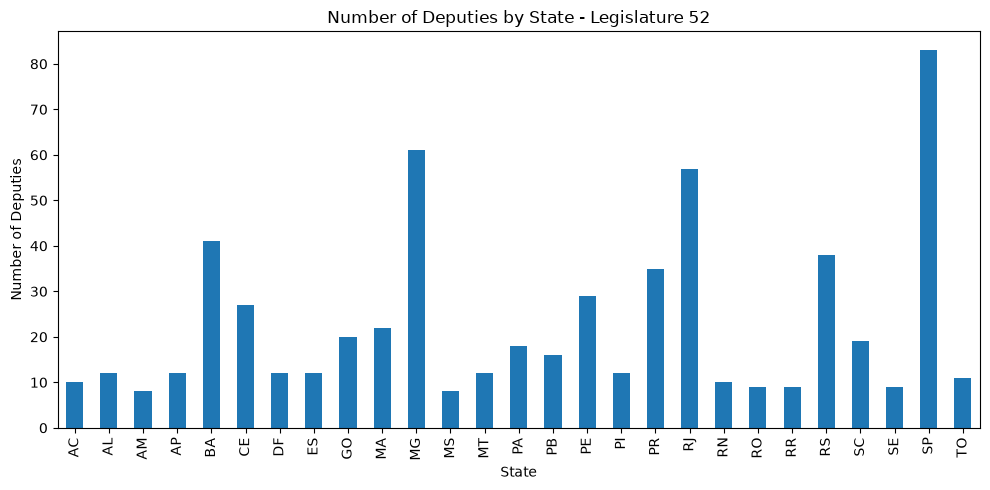

Saved figure: outputs/figures/deputies_by_state_legislature_53.png


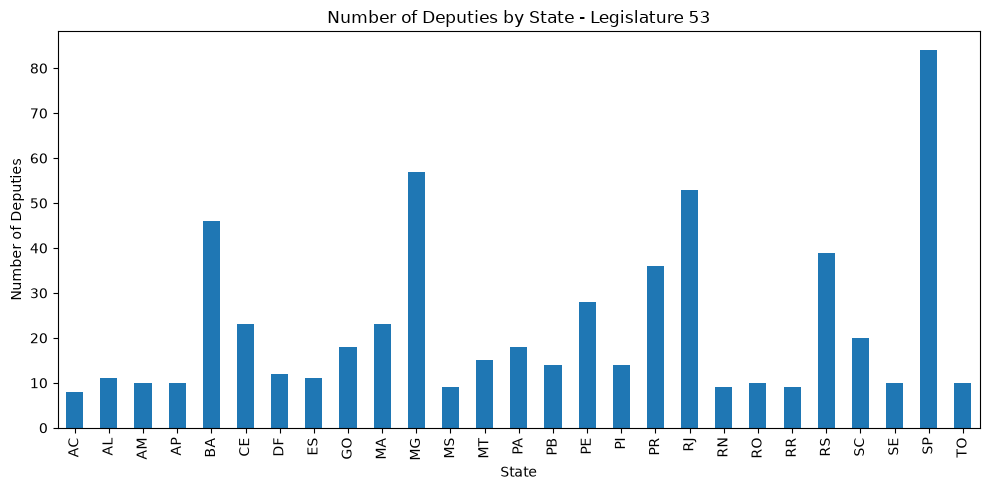

Saved figure: outputs/figures/deputies_by_state_legislature_54.png


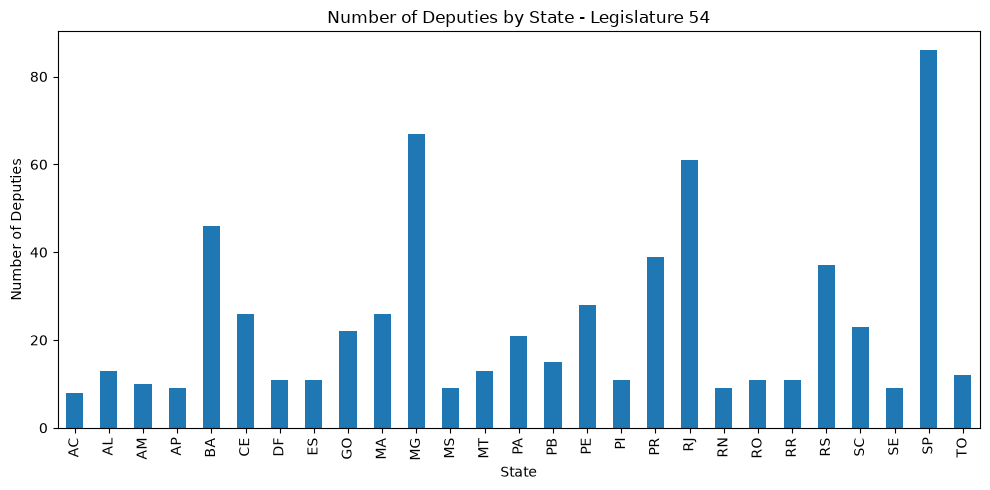

Saved figure: outputs/figures/deputies_by_state_legislature_55.png


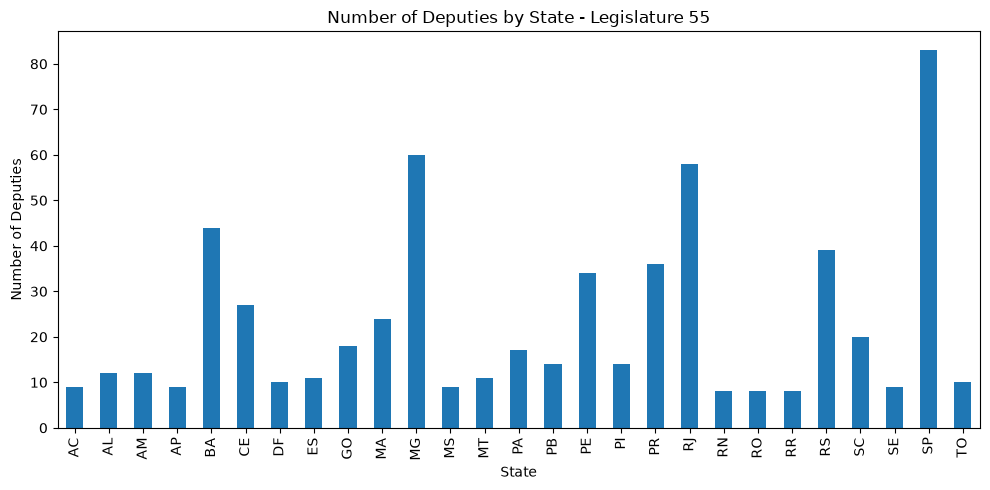

Saved figure: outputs/figures/deputies_by_state_legislature_56.png


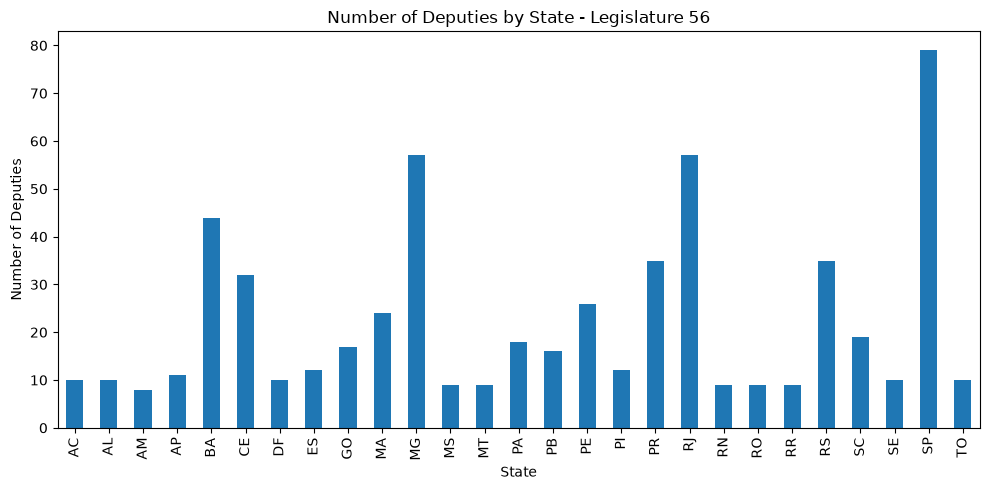

Saved figure: outputs/figures/deputies_by_state_legislature_57.png


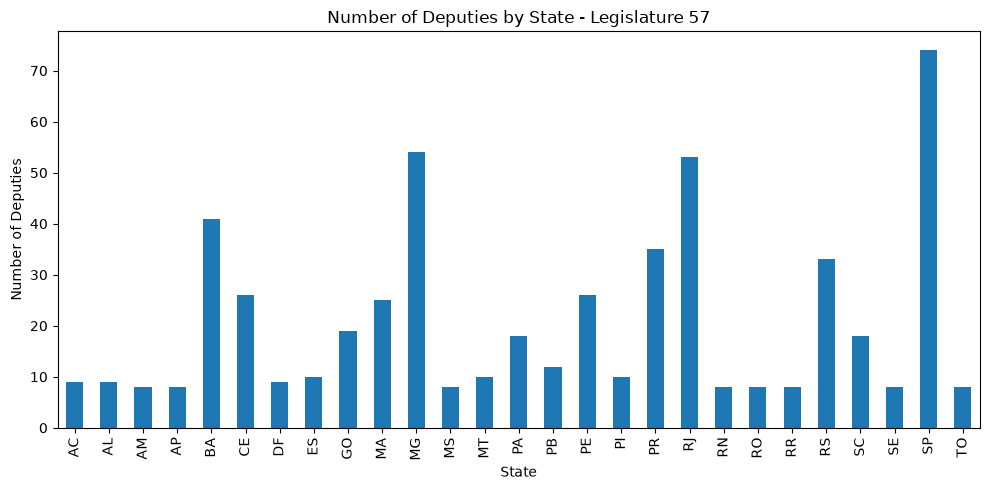

Saved table: outputs/tables/deputies_by_state_and_legislature.csv


PosixPath('/home/carlos/Carlos/Bahia_Clean_Project/outputs/tables/deputies_by_state_and_legislature.csv')

In [6]:
# =============================================================================
# 5. DEPUTIES BY STATE AND LEGISLATURE
# =============================================================================

unique_deputies = superplanilha_red.drop_duplicates(
    subset=["deputado_id", "Uf", "Legislatura"]
)

print(
    f"Unique deputies in the complete database: "
    f"{superplanilha_red['deputado_id'].nunique():,}"
)

state_count_tables = []

for legislature in LEGISLATURES:
    state_counts = (
        unique_deputies.loc[
            unique_deputies["Legislatura"].eq(legislature),
            "Uf",
        ]
        .value_counts()
        .sort_index()
    )

    state_table = state_counts.rename("Deputies").reset_index()
    state_table.columns = ["State", "Deputies"]
    state_table.insert(0, "Legislature", legislature)
    state_count_tables.append(state_table)

    fig, ax = plt.subplots(figsize=(10, 5))
    state_counts.plot(kind="bar", ax=ax)
    ax.set_title(f"Number of Deputies by State - Legislature {legislature}")
    ax.set_xlabel("State")
    ax.set_ylabel("Number of Deputies")
    fig.tight_layout()
    save_figure(fig, f"deputies_by_state_legislature_{legislature}.png")
    plt.show()

state_counts_all = pd.concat(state_count_tables, ignore_index=True)
save_table(state_counts_all, "deputies_by_state_and_legislature.csv", index=False)


## 6. Example state comparison

In [7]:
# =============================================================================
# 6. EXAMPLE STATE COMPARISON: SP AND MS
# =============================================================================

comparison_rows = []

for legislature in (52, 57):
    counts = (
        superplanilha_red.loc[
            superplanilha_red["Legislatura"].eq(legislature)
            & superplanilha_red["Uf"].isin(["SP", "MS"])
        ]
        .groupby("Uf")["deputado_id"]
        .nunique()
        .reindex(["SP", "MS"], fill_value=0)
    )

    comparison_rows.append(
        {
            "Legislature": legislature,
            "SP": int(counts["SP"]),
            "MS": int(counts["MS"]),
        }
    )

state_comparison = pd.DataFrame(comparison_rows)
display(state_comparison)
save_table(state_comparison, "state_comparison_sp_ms.csv", index=False)


,Legislature,SP,MS
0,52,83,8
1,57,74,8


Saved table: outputs/tables/state_comparison_sp_ms.csv


PosixPath('/home/carlos/Carlos/Bahia_Clean_Project/outputs/tables/state_comparison_sp_ms.csv')

## 7. Number of unique parties by legislature

,Original Parties,Adjusted Parties
Legislatura,,
52,24,20
53,23,20
54,29,24
55,36,26
56,36,25
57,23,21


Saved figure: outputs/figures/unique_parties_original.png


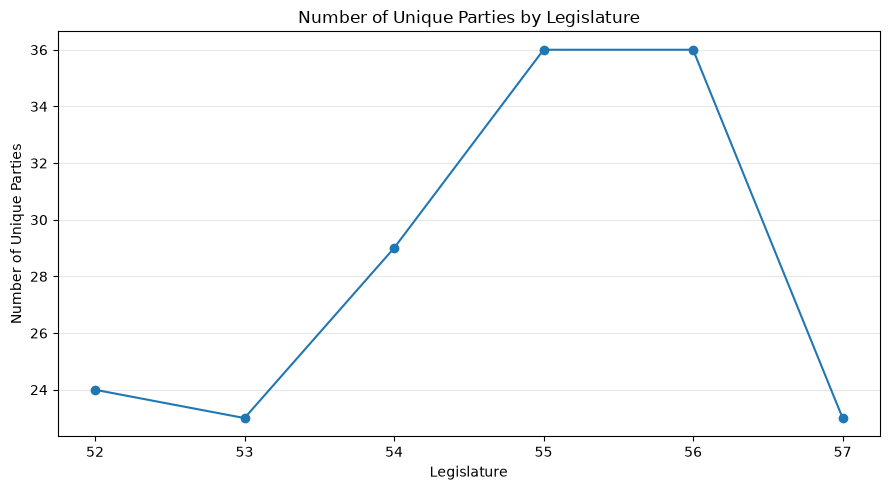

Saved figure: outputs/figures/unique_parties_adjusted.png


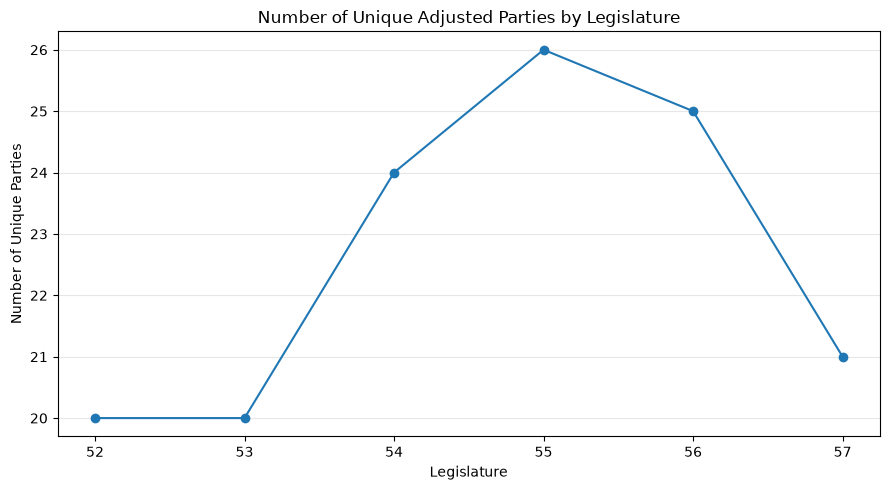

Saved table: outputs/tables/unique_parties_by_legislature.csv


PosixPath('/home/carlos/Carlos/Bahia_Clean_Project/outputs/tables/unique_parties_by_legislature.csv')

In [8]:
# =============================================================================
# 7. NUMBER OF UNIQUE PARTIES BY LEGISLATURE
# =============================================================================

original_party_counts = unique_party_counts(superplanilha_red, "Partidos")
adjusted_party_counts = unique_party_counts(
    superplanilha_red, "Partidos Ajustados"
)

party_count_summary = pd.DataFrame(
    {
        "Original Parties": original_party_counts,
        "Adjusted Parties": adjusted_party_counts,
    }
)

display(party_count_summary)

plot_party_counts(
    original_party_counts,
    "Number of Unique Parties by Legislature",
    "Number of Unique Parties",
    "unique_parties_original.png",
)

plot_party_counts(
    adjusted_party_counts,
    "Number of Unique Adjusted Parties by Legislature",
    "Number of Unique Parties",
    "unique_parties_adjusted.png",
)

save_table(party_count_summary, "unique_parties_by_legislature.csv")


## 8. Party composition by legislature

Partidos Ajustados,TOTAL,STANDARD_SEATS,NORMALIZATION_FACTOR,AGIR,AVANTE,CIDADANIA,DC,MDB,NOVO,PATRIOTA,...,PSDB,PSOL,PT,PTB,PV,REDE,REPUBLICANOS,S.PART.,SOLIDARIEDADE,UNIÃO
Legislatura,,,,,,,,,,,,,,,,,,,,,
52,843,513,0.608541,1,0,32,0,127,0,1,...,94,7,107,72,9,0,2,37,0,98
53,689,513,0.744557,5,1,23,0,118,0,0,...,78,4,97,36,16,0,10,6,0,80
54,798,513,0.642857,1,4,16,1,109,0,8,...,74,3,112,29,15,0,15,5,45,57
55,873,513,0.587629,2,9,16,2,98,0,10,...,68,7,76,29,12,5,31,13,53,64
56,811,513,0.632552,2,10,11,1,51,8,10,...,43,11,61,14,8,2,61,6,33,113
57,566,513,0.906360,0,7,5,0,46,3,7,...,14,13,69,0,6,1,50,3,7,64


Saved figure: outputs/figures/deputies_by_party_and_legislature.png


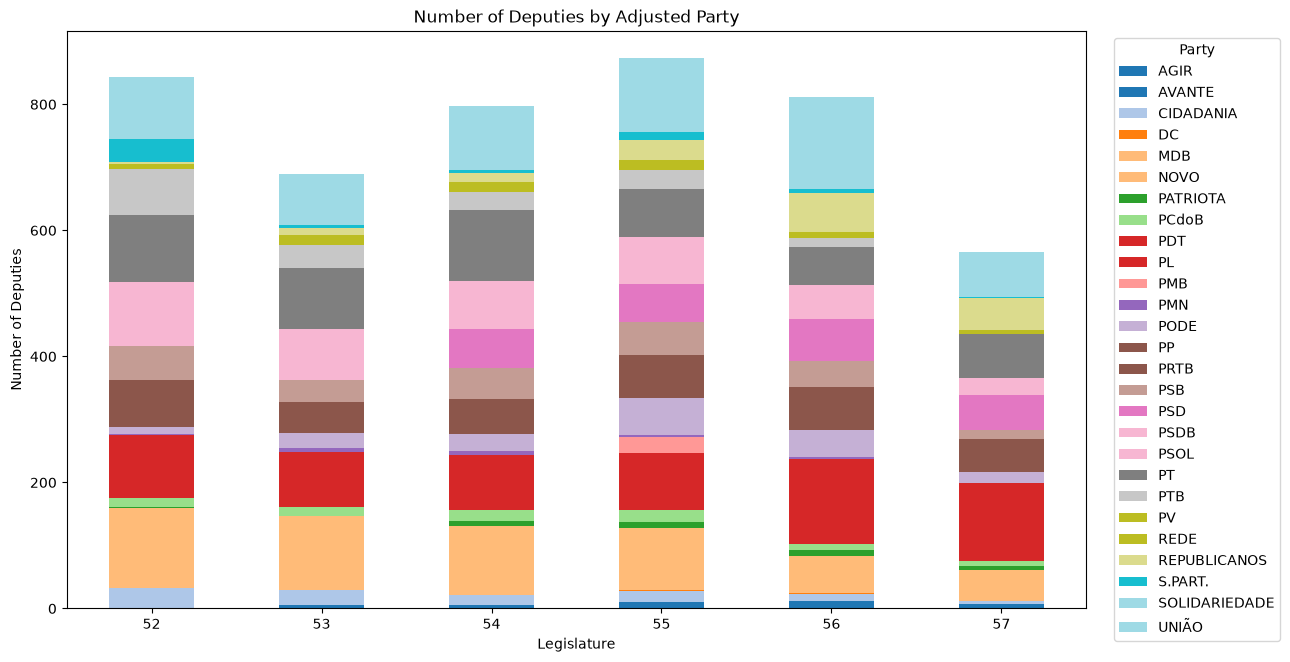

Saved figure: outputs/figures/normalized_deputies_by_party_and_legislature.png


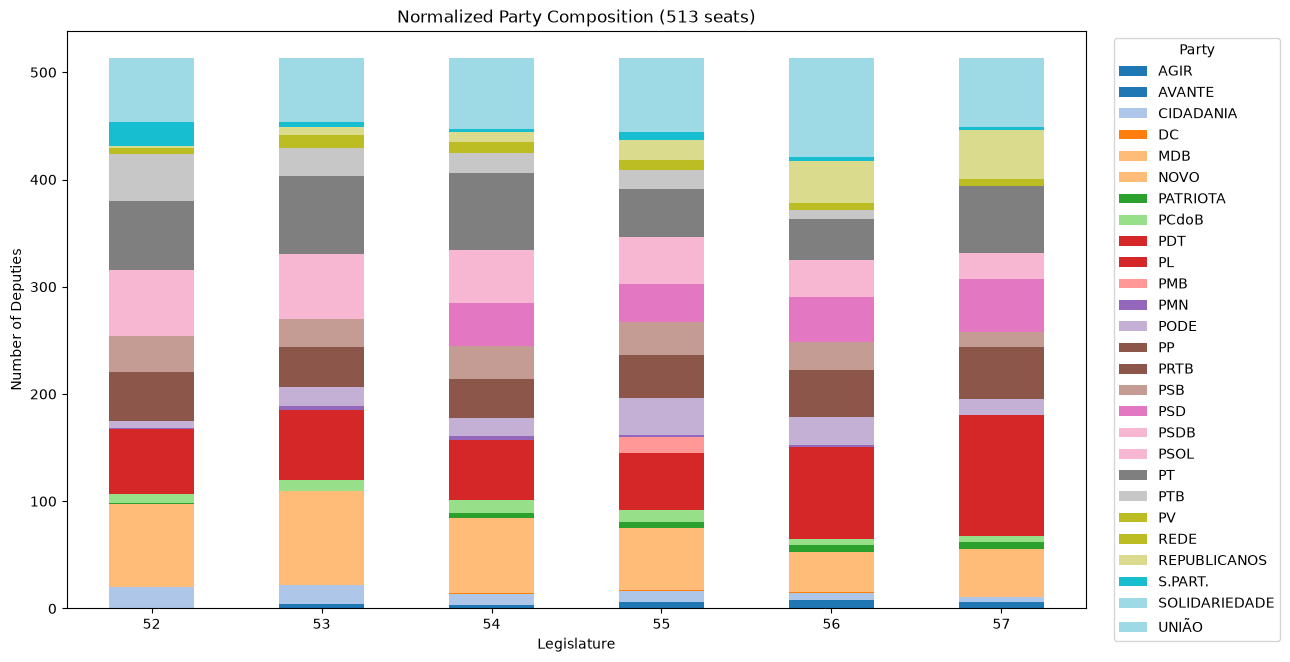

Saved table: outputs/tables/deputies_by_party_and_legislature.csv
Saved table: outputs/tables/normalized_party_composition.csv


PosixPath('/home/carlos/Carlos/Bahia_Clean_Project/outputs/tables/normalized_party_composition.csv')

In [9]:
# =============================================================================
# 8. PARTY COMPOSITION BY LEGISLATURE
# =============================================================================

(
    unique_deputy_party_rows,
    party_counts_by_legislature,
    normalized_party_counts,
    party_composition_summary,
) = build_legislature_party_table(superplanilha_red)

# Compatibility objects retained from the original notebook.
novo_dataframe_sem_duplicatas = unique_deputy_party_rows
novo_dataframe = superplanilha_red[
    ["deputado_nome", "Legislatura", "Partidos Ajustados"]
].copy()
novo_dataframe_menor = unique_deputy_party_rows[
    ["Legislatura", "Partidos Ajustados"]
].copy()
contagem_partidos_por_legislatura_2 = party_composition_summary

display(party_composition_summary)

plot_stacked_party_table(
    party_counts_by_legislature,
    "Number of Deputies by Adjusted Party",
    "deputies_by_party_and_legislature.png",
)

plot_stacked_party_table(
    normalized_party_counts,
    f"Normalized Party Composition ({STANDARD_CHAMBER_SIZE} seats)",
    "normalized_deputies_by_party_and_legislature.png",
)

save_table(
    party_counts_by_legislature,
    "deputies_by_party_and_legislature.csv",
)
save_table(
    normalized_party_counts,
    "normalized_party_composition.csv",
)


## 9. Deputies and substitutes by legislature

,Legislature,Unique Deputies,Regular Seats,Additional Deputies / Substitutes
0,52,611,513,98
1,53,606,513,93
2,54,645,513,132
3,55,614,513,101
4,56,597,513,84
5,57,555,513,42


Saved table: outputs/tables/deputies_and_substitutes_by_legislature.csv
Saved figure: outputs/figures/deputies_and_substitutes_by_legislature.png


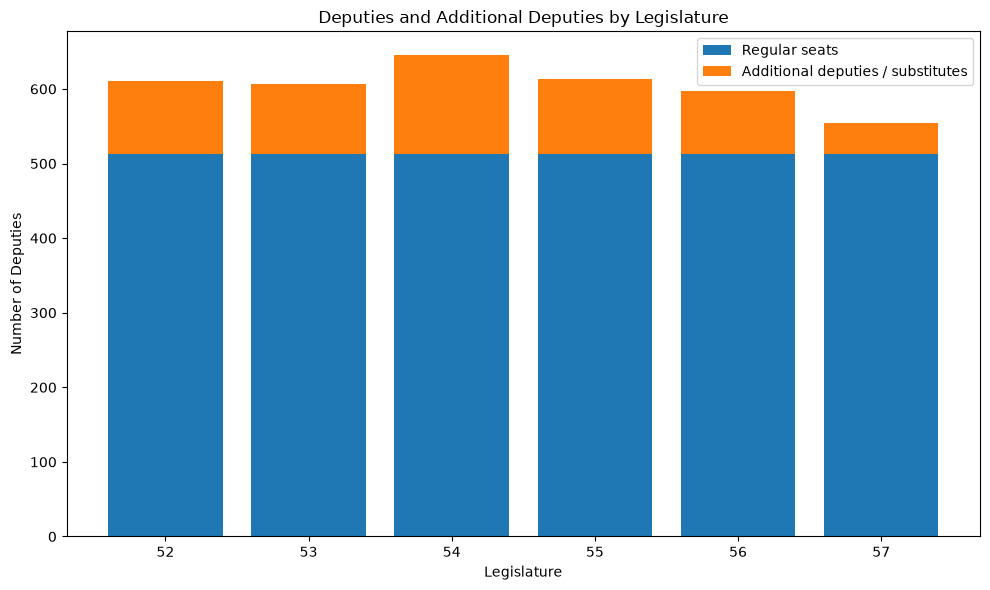

In [10]:
# =============================================================================
# 9. DEPUTIES AND ADDITIONAL DEPUTIES / SUBSTITUTES BY LEGISLATURE
# =============================================================================

deputies_by_legislature = (
    superplanilha_red.groupby("Legislatura")["deputado_id"]
    .nunique()
    .reindex(LEGISLATURES)
)

legislature_summary = pd.DataFrame(
    {
        "Legislature": deputies_by_legislature.index,
        "Unique Deputies": deputies_by_legislature.values,
    }
)

legislature_summary["Regular Seats"] = np.minimum(
    legislature_summary["Unique Deputies"],
    STANDARD_CHAMBER_SIZE,
)

legislature_summary["Additional Deputies / Substitutes"] = np.maximum(
    legislature_summary["Unique Deputies"] - STANDARD_CHAMBER_SIZE,
    0,
)

display(legislature_summary)
save_table(
    legislature_summary,
    "deputies_and_substitutes_by_legislature.csv",
    index=False,
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(
    legislature_summary["Legislature"],
    legislature_summary["Regular Seats"],
    label="Regular seats",
)
ax.bar(
    legislature_summary["Legislature"],
    legislature_summary["Additional Deputies / Substitutes"],
    bottom=legislature_summary["Regular Seats"],
    label="Additional deputies / substitutes",
)
ax.set_xlabel("Legislature")
ax.set_ylabel("Number of Deputies")
ax.set_title("Deputies and Additional Deputies by Legislature")
ax.legend()
fig.tight_layout()
save_figure(fig, "deputies_and_substitutes_by_legislature.png")
plt.show()


## 10. Parliamentary fronts

,Fronts,Unique Coordinators
idLegislatura,,
52,113,98
53,99,92
54,214,159
55,345,214
56,352,219
57,320,209


Saved table: outputs/tables/parliamentary_fronts_by_legislature.csv
Saved figure: outputs/figures/parliamentary_fronts_by_legislature.png


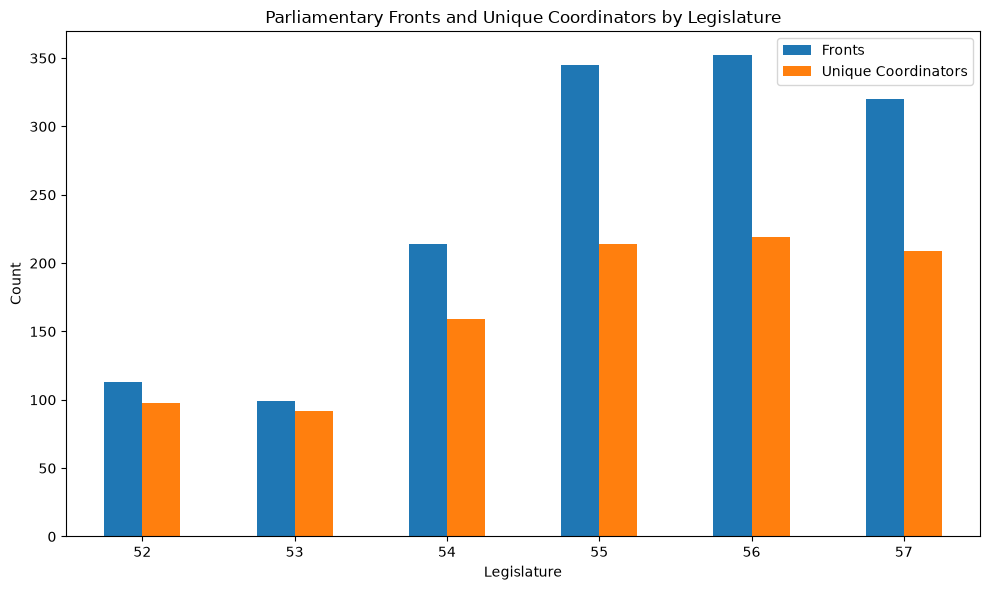

Saved figure: outputs/figures/parliamentary_fronts_distribution.png


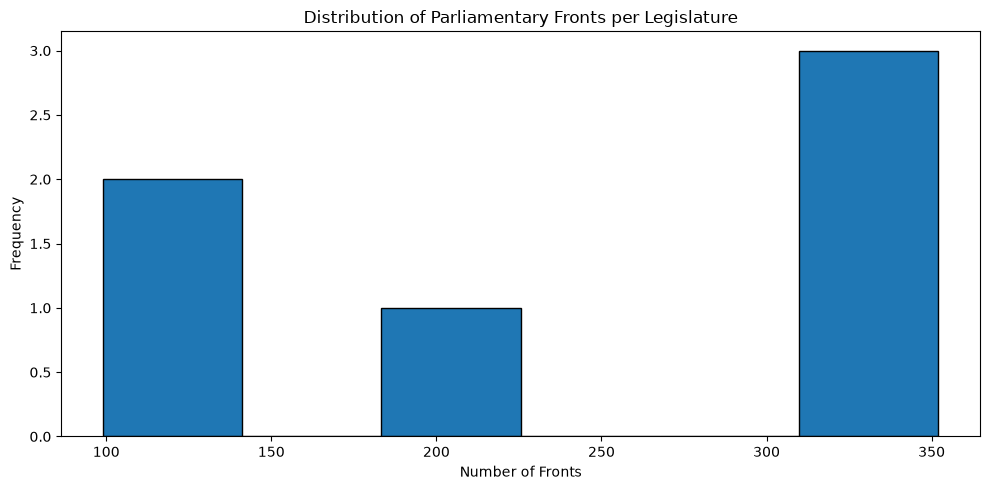

In [11]:
# =============================================================================
# 10. PARLIAMENTARY FRONTS
# =============================================================================

fronts_by_legislature = (
    frentes_red["idLegislatura"]
    .value_counts()
    .sort_index()
)

coordinators_by_legislature = (
    frentes_red.groupby("idLegislatura")["coordenador_nome"]
    .nunique()
)

front_summary = pd.concat(
    [
        fronts_by_legislature.rename("Fronts"),
        coordinators_by_legislature.rename("Unique Coordinators"),
    ],
    axis=1,
).fillna(0)

display(front_summary)
save_table(
    front_summary,
    "parliamentary_fronts_by_legislature.csv",
)

fig, ax = plt.subplots(figsize=(10, 6))
front_summary.plot(kind="bar", ax=ax)
ax.set_title("Parliamentary Fronts and Unique Coordinators by Legislature")
ax.set_xlabel("Legislature")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=0)
fig.tight_layout()
save_figure(fig, "parliamentary_fronts_by_legislature.png")
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(fronts_by_legislature.values, bins=min(10, len(fronts_by_legislature)), edgecolor="black")
ax.set_title("Distribution of Parliamentary Fronts per Legislature")
ax.set_xlabel("Number of Fronts")
ax.set_ylabel("Frequency")
fig.tight_layout()
save_figure(fig, "parliamentary_fronts_distribution.png")
plt.show()


## 11. Vote types by legislature

Legislatura,52,53,54,55,56,57,Total
voto,,,,,,,
Abstenção,524,708,797,1985,1678,359,6051
Artigo 17,228,433,372,865,1754,277,3929
Branco,0,3,0,0,0,0,3
Favorável com restrições,29,0,0,0,0,0,29
Não,32143,62106,48060,129443,362002,49937,683691
Obstrução,4831,7189,3612,18440,13666,3222,50960
Sim,37687,70974,70136,157170,420647,74884,831498


Saved table: outputs/tables/vote_types_by_legislature.csv
Saved table: outputs/tables/vote_type_percentages_by_legislature.csv
Saved figure: outputs/figures/vote_types_by_legislature.png


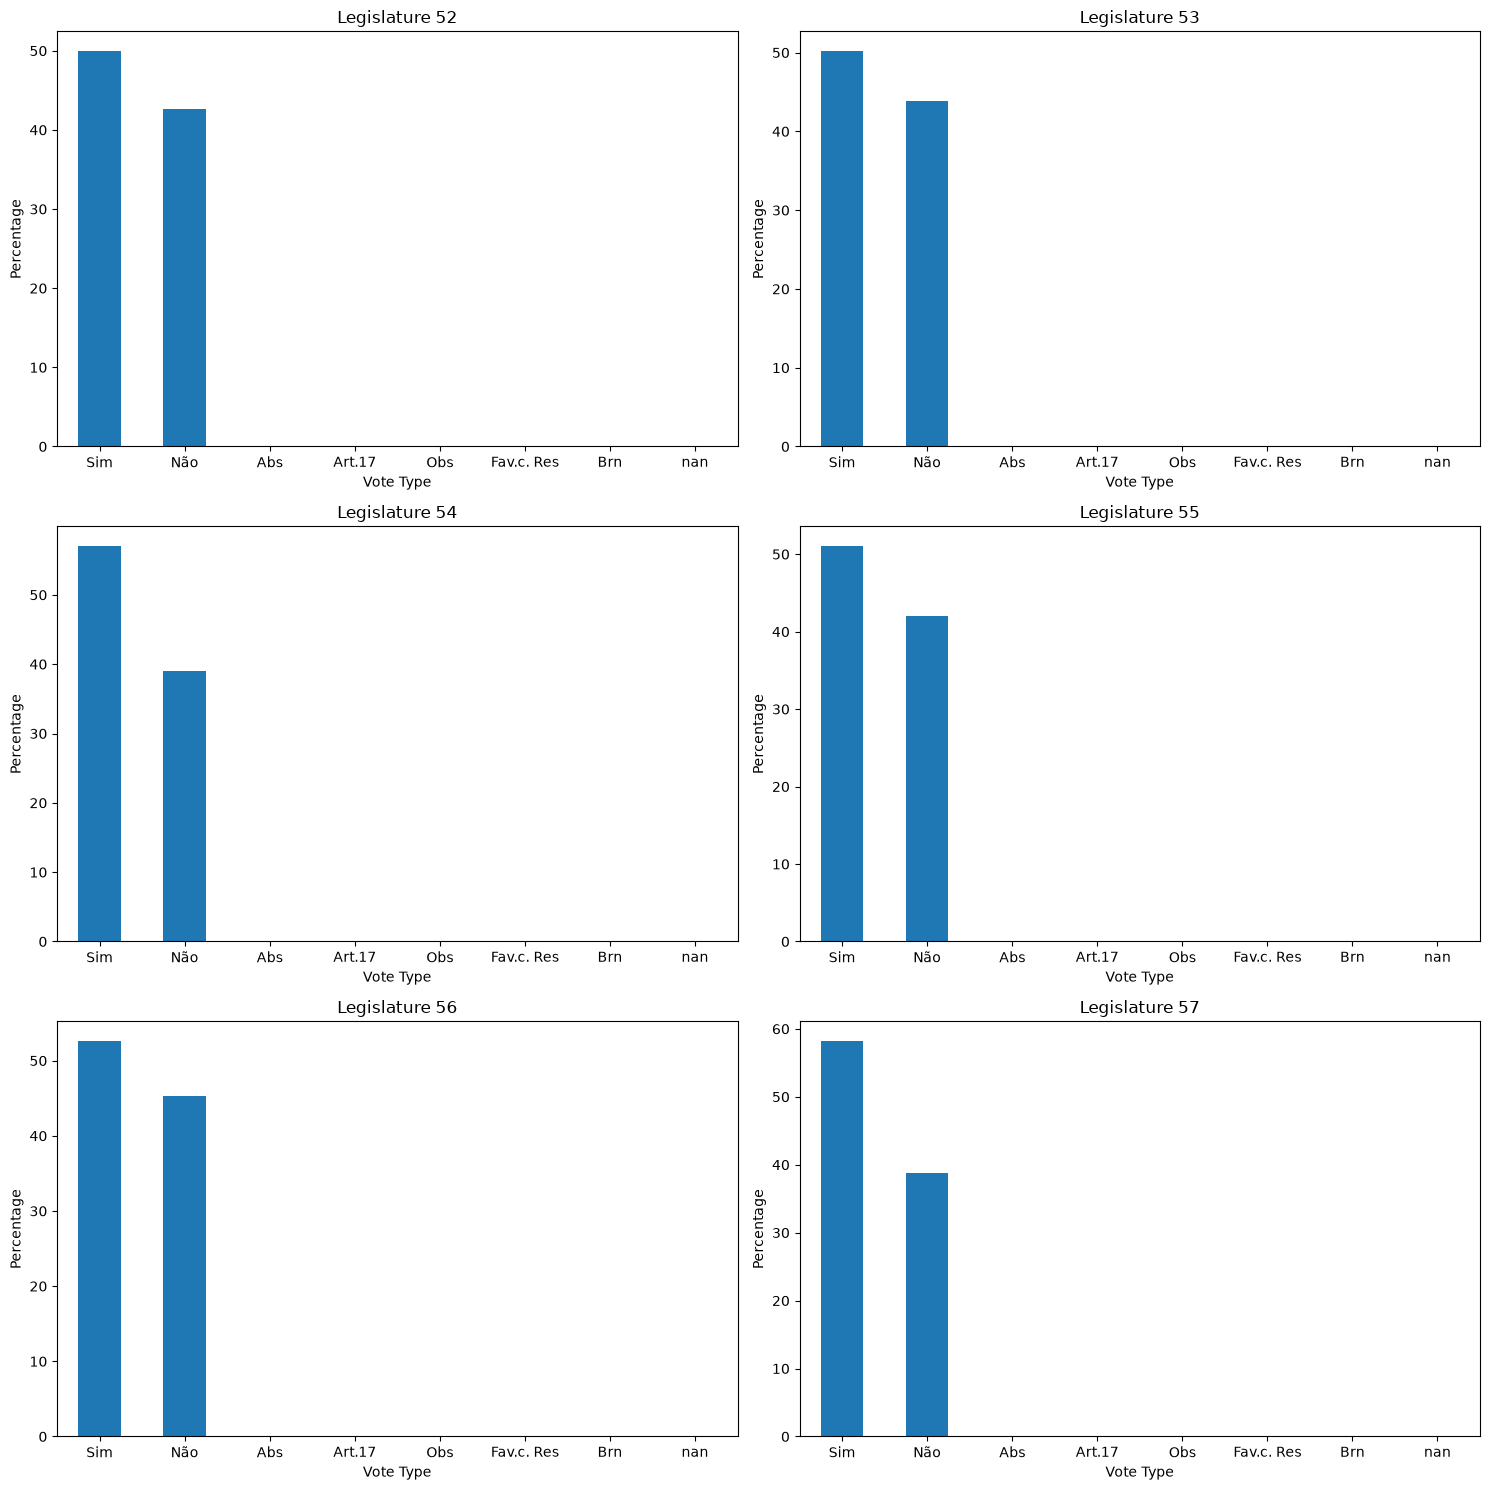

In [12]:
# =============================================================================
# 11. VOTE TYPES BY LEGISLATURE
# =============================================================================

vote_type_order = [
    "Sim",
    "Não",
    "Abs",
    "Art.17",
    "Obs",
    "Fav.c. Res",
    "Brn",
    "nan",
]

vote_type_percent = (
    superplanilha_red.groupby("Legislatura")["voto"]
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
    .reindex(index=LEGISLATURES, columns=vote_type_order, fill_value=0)
    .mul(100)
)

vote_type_counts = (
    superplanilha_red.pivot_table(
        index="voto",
        columns="Legislatura",
        aggfunc="size",
        fill_value=0,
    )
)
vote_type_counts["Total"] = vote_type_counts.sum(axis=1)

display(vote_type_counts)
save_table(vote_type_counts, "vote_types_by_legislature.csv")
save_table(vote_type_percent, "vote_type_percentages_by_legislature.csv")

fig, axes = plt.subplots(3, 2, figsize=(15, 15))

for axis, legislature in zip(axes.flat, LEGISLATURES):
    vote_type_percent.loc[legislature].plot(kind="bar", ax=axis)
    axis.set_title(f"Legislature {legislature}")
    axis.set_xlabel("Vote Type")
    axis.set_ylabel("Percentage")
    axis.tick_params(axis="x", rotation=0)

fig.tight_layout()
save_figure(fig, "vote_types_by_legislature.png")
plt.show()


## 12. Party voting correlations

For each roll call and party, the score is:

\[
	ext{score} = \#(	ext{Yes}) - \#(	ext{No})
\]

All other vote categories contribute zero to this score, matching the logic of the original notebook.


Saved figure: outputs/figures/party_correlation_original.png


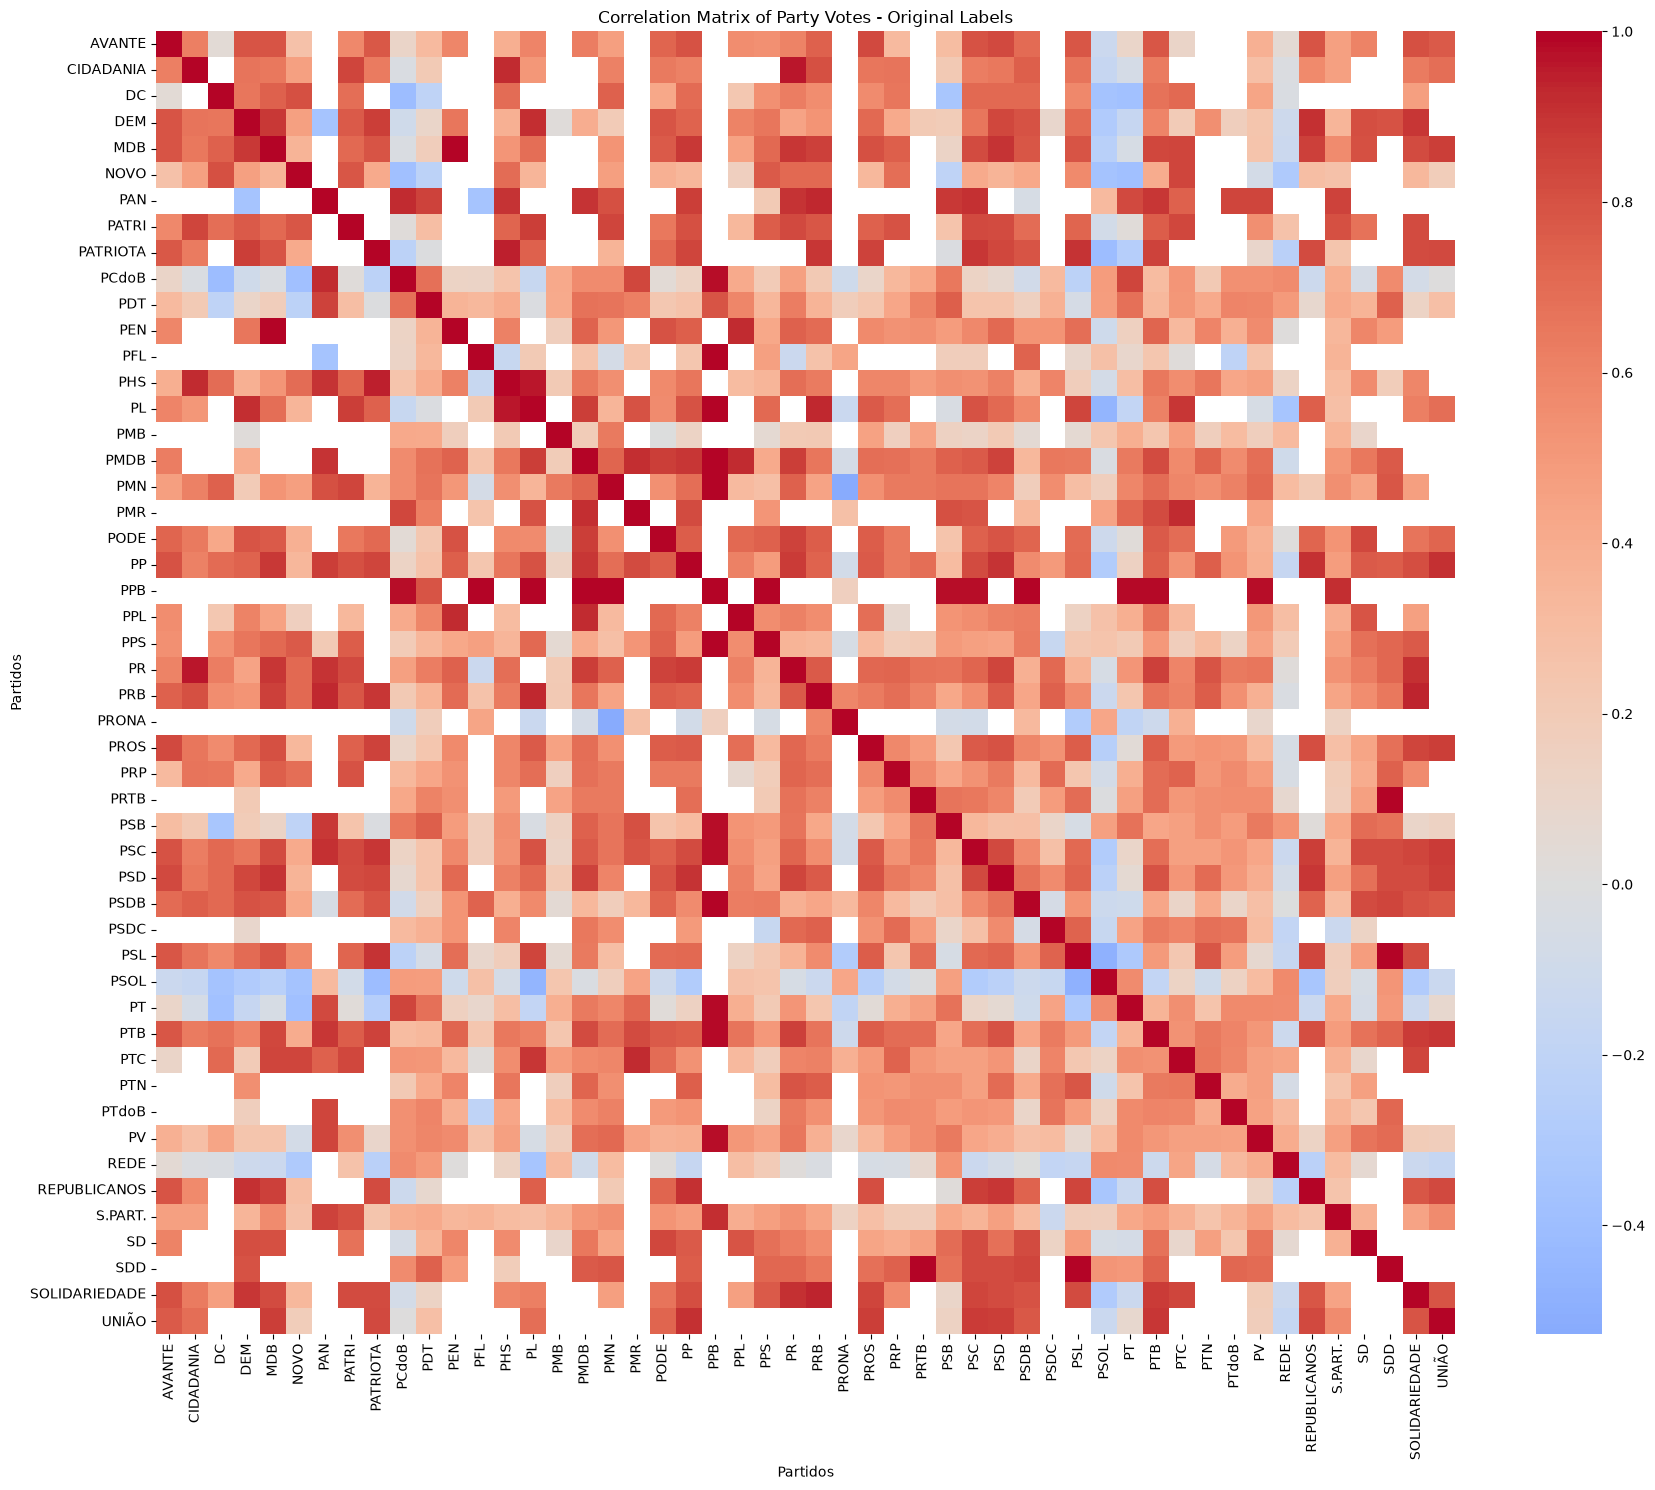

Saved figure: outputs/figures/party_correlation_adjusted.png


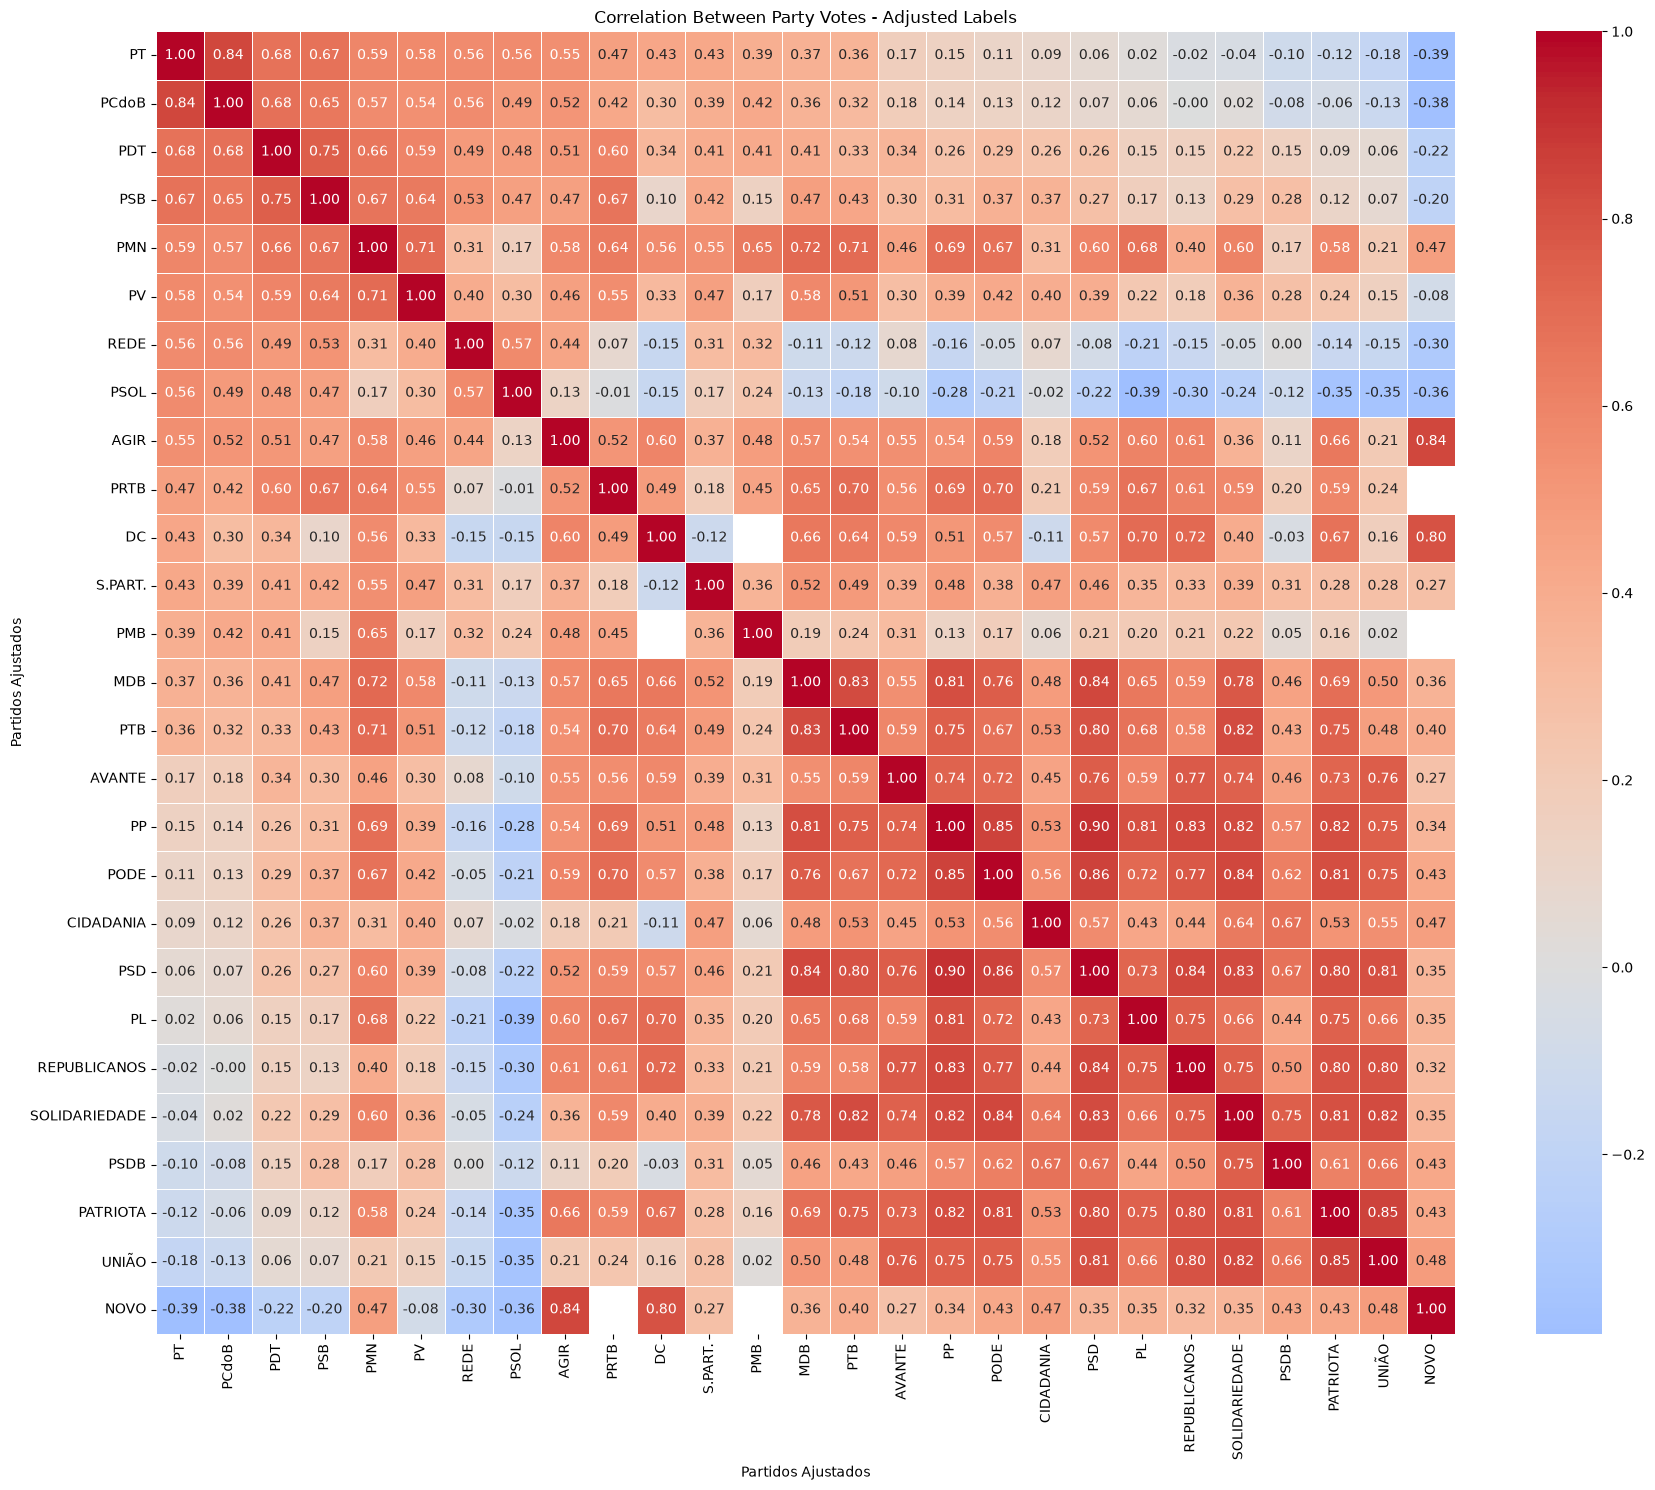

Saved table: outputs/tables/party_correlation_original.csv
Saved table: outputs/tables/party_correlation_adjusted.csv


PosixPath('/home/carlos/Carlos/Bahia_Clean_Project/outputs/tables/party_correlation_adjusted.csv')

In [13]:
# =============================================================================
# 12. PARTY VOTING CORRELATIONS
# =============================================================================

# Original labels
votos_pivot_1, correlation_matrix_1 = build_vote_correlation(
    superplanilha_red,
    "Partidos",
)

# Harmonized labels
votos_pivot_ajus, correlation_matrix_ajus = build_vote_correlation(
    superplanilha_red,
    "Partidos Ajustados",
)

# Compatibility alias from the original notebook.
correlation_matrix_ajus_3 = correlation_matrix_ajus.copy()

correlation_heatmap(
    correlation_matrix_1,
    "Correlation Matrix of Party Votes - Original Labels",
    "party_correlation_original.png",
    annotate=False,
)

ordered_correlation_matrix = correlation_heatmap(
    correlation_matrix_ajus,
    "Correlation Between Party Votes - Adjusted Labels",
    "party_correlation_adjusted.png",
    annotate=True,
    order_by="PT",
)

save_table(
    correlation_matrix_1,
    "party_correlation_original.csv",
)
save_table(
    correlation_matrix_ajus,
    "party_correlation_adjusted.csv",
)


## 13. Correlation among selected major parties

Saved figure: outputs/figures/party_correlation_selected_parties.png


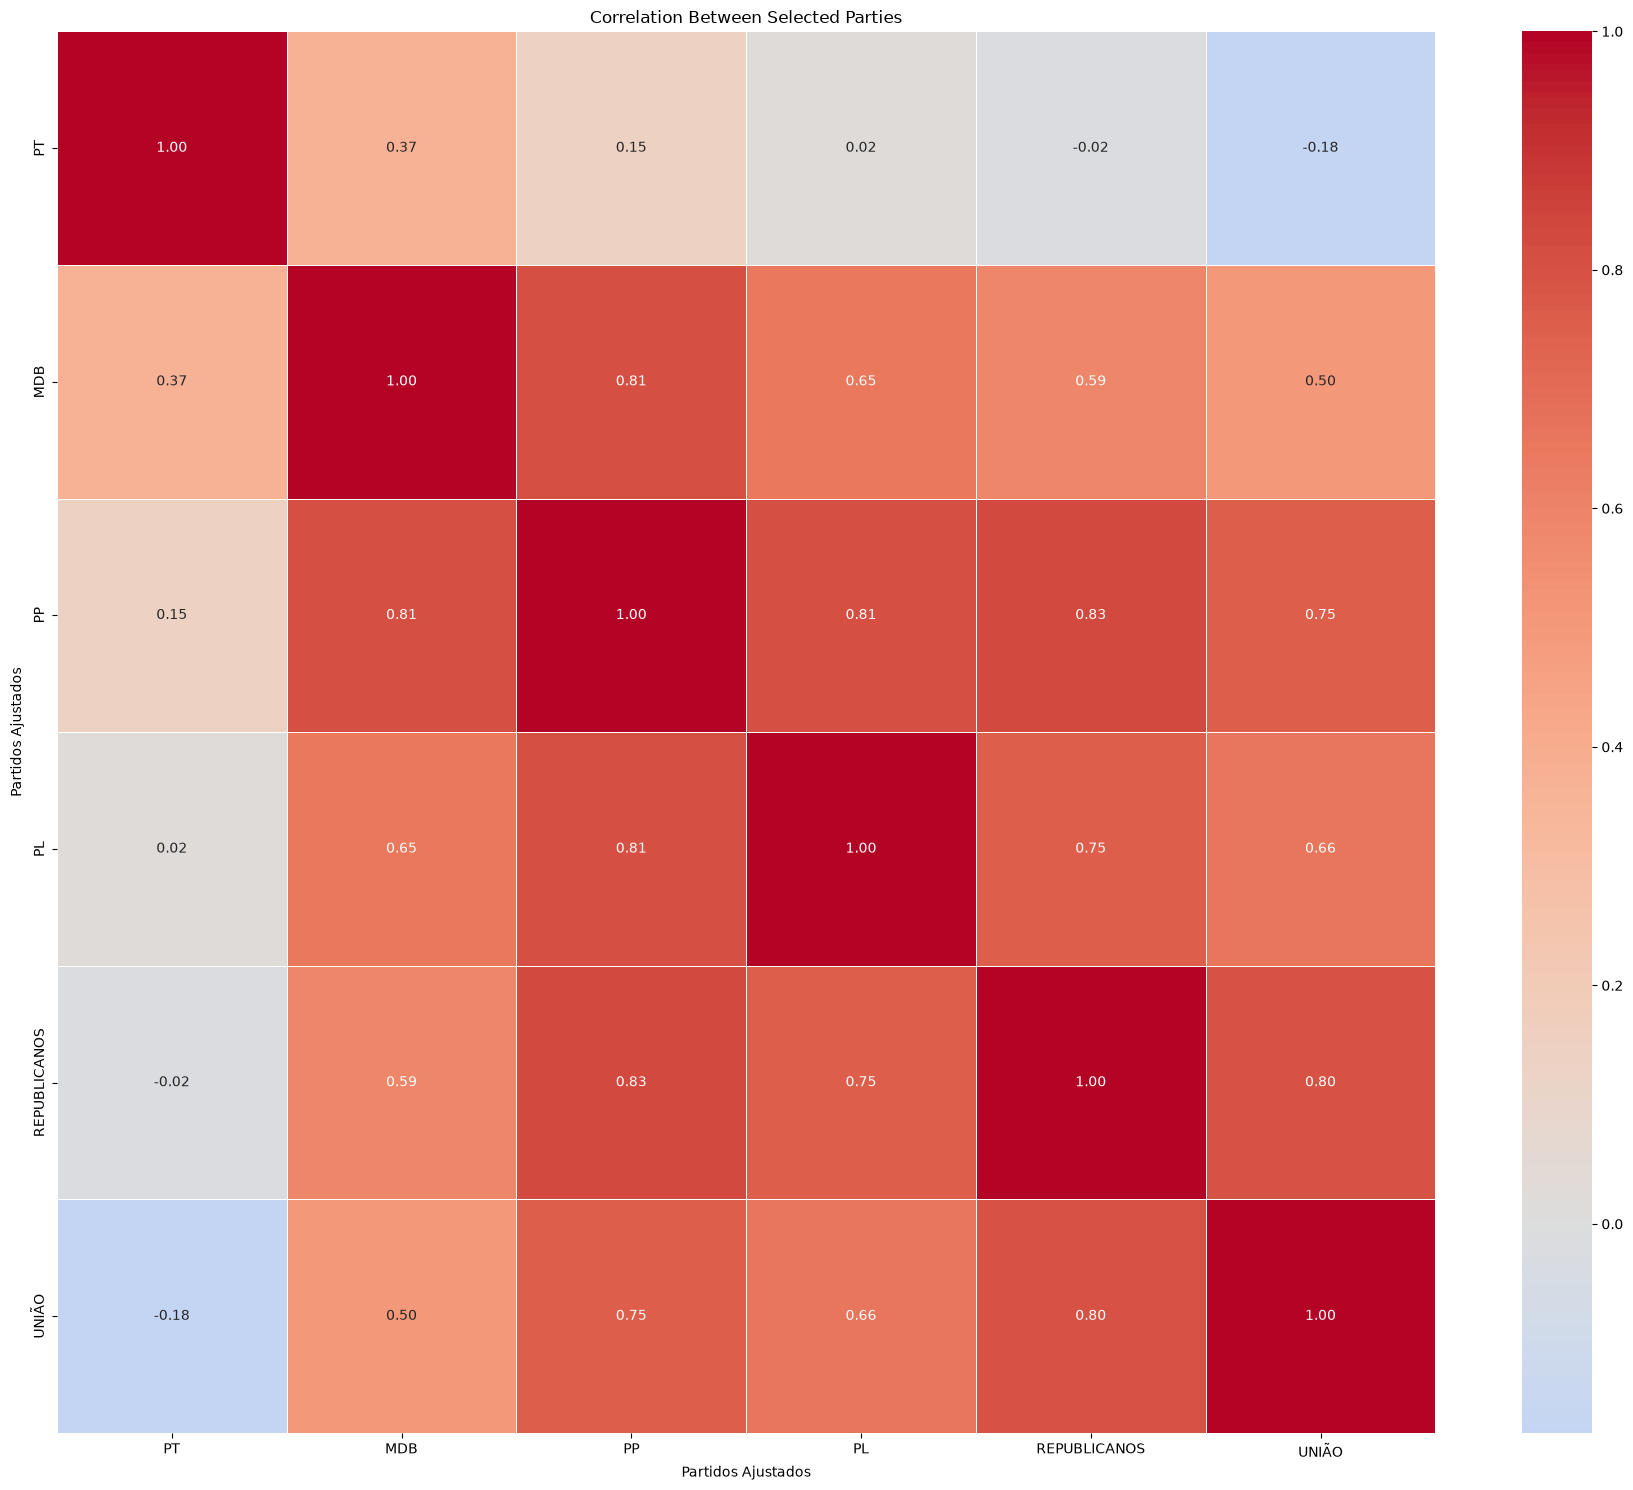

Partidos Ajustados,MDB,PL,PP,PT,REPUBLICANOS,UNIÃO
Partidos Ajustados,,,,,,
MDB,1.000000,0.648920,0.811008,0.372992,0.589566,0.502982
PL,0.648920,1.000000,0.809539,0.019498,0.753482,0.660561
PP,0.811008,0.809539,1.000000,0.145619,0.832199,0.751655
PT,0.372992,0.019498,0.145619,1.000000,-0.023756,-0.175399
REPUBLICANOS,0.589566,0.753482,0.832199,-0.023756,1.000000,0.795572
UNIÃO,0.502982,0.660561,0.751655,-0.175399,0.795572,1.000000


Saved table: outputs/tables/party_correlation_selected_parties.csv


PosixPath('/home/carlos/Carlos/Bahia_Clean_Project/outputs/tables/party_correlation_selected_parties.csv')

In [14]:
# =============================================================================
# 13. CORRELATION AMONG SELECTED MAJOR PARTIES
# =============================================================================

major_party_votes = superplanilha_red.loc[
    superplanilha_red["Partidos Ajustados"].isin(FOCUS_PARTIES)
].copy()

votos_pivot_imp, correlation_matrix_imp = build_vote_correlation(
    major_party_votes,
    "Partidos Ajustados",
)

focus_correlation_matrix = correlation_heatmap(
    correlation_matrix_imp,
    "Correlation Between Selected Parties",
    "party_correlation_selected_parties.png",
    annotate=True,
    order_by="PT",
)

display(correlation_matrix_imp)
save_table(
    correlation_matrix_imp,
    "party_correlation_selected_parties.csv",
)


## 14. Correlation network

Saved figure: outputs/figures/party_correlation_network.png


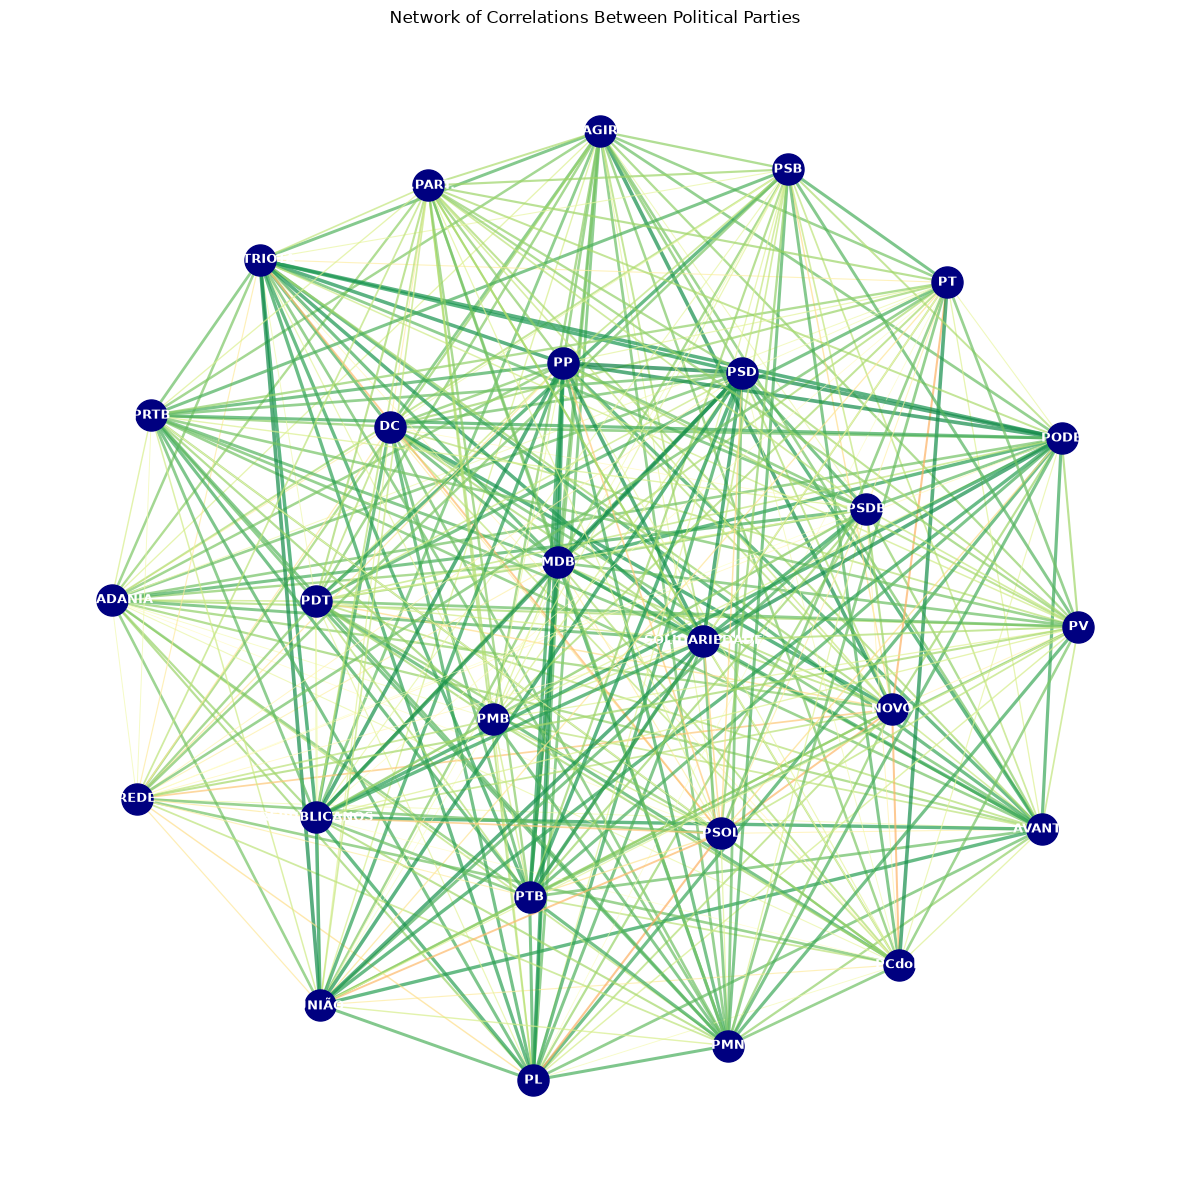

Saved table: outputs/tables/party_correlation_network_edges.csv


PosixPath('/home/carlos/Carlos/Bahia_Clean_Project/outputs/tables/party_correlation_network_edges.csv')

In [15]:
# =============================================================================
# 14. CORRELATION NETWORK
# =============================================================================

G = build_correlation_network(correlation_matrix_ajus)
positions = get_network_positions(G)

edge_weights = np.array(
    [data["weight"] for _, _, data in G.edges(data=True)],
    dtype=float,
)

edge_widths = (
    0.5 + 2.5 * np.abs(edge_weights)
    if edge_weights.size
    else np.array([])
)

fig, ax = plt.subplots(figsize=(12, 12))

nx.draw_networkx_nodes(
    G,
    positions,
    node_size=500,
    node_color="navy",
    ax=ax,
)

nx.draw_networkx_labels(
    G,
    positions,
    font_size=9,
    font_color="white",
    font_weight="bold",
    ax=ax,
)

if edge_weights.size:
    nx.draw_networkx_edges(
        G,
        positions,
        width=edge_widths,
        edge_color=edge_weights,
        edge_cmap=plt.cm.RdYlGn,
        edge_vmin=-1,
        edge_vmax=1,
        alpha=0.7,
        ax=ax,
    )

ax.set_title("Network of Correlations Between Political Parties")
ax.axis("off")
fig.tight_layout()
save_figure(fig, "party_correlation_network.png")
plt.show()

network_edges = pd.DataFrame(
    [
        {
            "Party 1": u,
            "Party 2": v,
            "Correlation": data["weight"],
        }
        for u, v, data in G.edges(data=True)
    ]
)
save_table(network_edges, "party_correlation_network_edges.csv", index=False)


## 15. Total votes and average votes per deputy

,Average Votes per Deputy
Partidos Ajustados,
AGIR,104.900000
AVANTE,669.000000
CIDADANIA,407.347826
DC,129.750000
MDB,478.956656
NOVO,2051.750000
PATRIOTA,403.709677
PCdoB,777.487805
PDT,637.280702


Total vote records: 1,579,848
Overall average vote records per deputy: 804.813
Saved table: outputs/tables/average_votes_by_party.csv
Saved figure: outputs/figures/average_votes_by_party.png


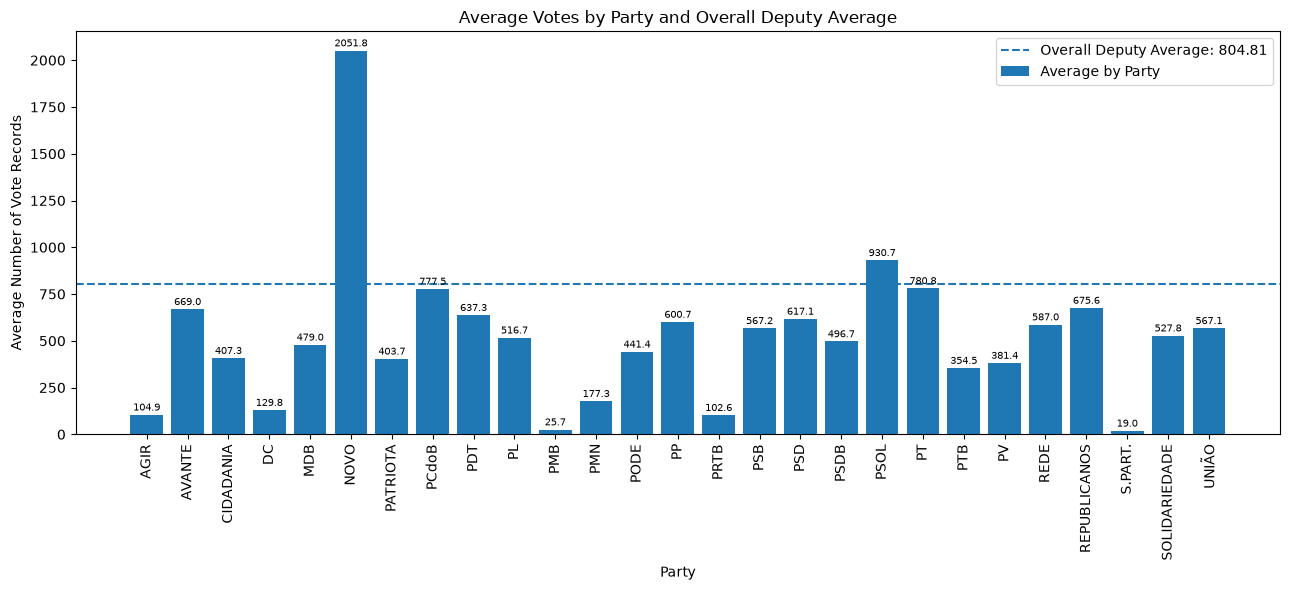

Overall deputy average: 804.812532
Mean of party averages: 519.609970
Are the two averages equal? False


In [16]:
# =============================================================================
# 15. TOTAL VOTES AND AVERAGE VOTES PER DEPUTY
# =============================================================================

total_votes = len(superplanilha_red)

overall_average_votes_per_deputy = (
    superplanilha_red.groupby("deputado_id")
    .size()
    .mean()
)

average_votes_by_party = (
    superplanilha_red
    .dropna(subset=["Partidos Ajustados", "deputado_id"])
    .groupby(["Partidos Ajustados", "deputado_id"])
    .size()
    .groupby(level=0)
    .mean()
    .sort_index()
)

vote_average_summary = (
    average_votes_by_party
    .rename("Average Votes per Deputy")
    .to_frame()
)

display(vote_average_summary)

print(f"Total vote records: {total_votes:,}")
print(
    f"Overall average vote records per deputy: "
    f"{overall_average_votes_per_deputy:.3f}"
)

save_table(
    vote_average_summary,
    "average_votes_by_party.csv",
)

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.bar(
    average_votes_by_party.index,
    average_votes_by_party.values,
    label="Average by Party",
)

ax.axhline(
    overall_average_votes_per_deputy,
    linestyle="--",
    label=f"Overall Deputy Average: {overall_average_votes_per_deputy:.2f}",
)

ax.set_xlabel("Party")
ax.set_ylabel("Average Number of Vote Records")
ax.set_title("Average Votes by Party and Overall Deputy Average")
ax.tick_params(axis="x", rotation=90)

for bar in bars:
    height = bar.get_height()
    ax.annotate(
        f"{height:.1f}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 3),
        textcoords="offset points",
        ha="center",
        fontsize=7,
    )

ax.legend()
fig.tight_layout()
save_figure(fig, "average_votes_by_party.png")
plt.show()

mean_of_party_averages = average_votes_by_party.mean()
averages_are_equal = np.isclose(
    overall_average_votes_per_deputy,
    mean_of_party_averages,
)

print(f"Overall deputy average: {overall_average_votes_per_deputy:.6f}")
print(f"Mean of party averages: {mean_of_party_averages:.6f}")
print(f"Are the two averages equal? {averages_are_equal}")


## 16. Votes by year and month

,ano,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,SUM
0,2015,0.0,2.878804,12.817134,6.224085,21.447396,13.027093,6.628189,8.614449,12.642315,6.093190,8.940368,0.686977,100.0
1,2019,0.0,6.364508,8.057742,0.731695,14.060123,4.162808,12.406575,17.849229,9.586448,7.010219,9.444242,10.326410,100.0
2,2020,0.0,4.454128,0.304914,10.487299,11.013230,15.230689,14.755474,4.538653,3.433573,0.000000,1.509545,34.272494,100.0
3,2021,0.0,4.532715,9.491264,5.169294,14.981797,10.669137,4.826640,14.796192,13.123892,7.372956,7.873280,7.162832,100.0
4,2022,0.0,15.883591,13.456537,10.971684,16.121885,7.235531,7.499176,12.976906,0.014703,1.500241,5.109641,9.230106,100.0


Saved table: outputs/tables/votes_by_year.csv
Saved table: outputs/tables/votes_by_year_and_month.csv
Saved table: outputs/tables/monthly_vote_share_by_year.csv
Saved figure: outputs/figures/votes_by_year_and_month.png


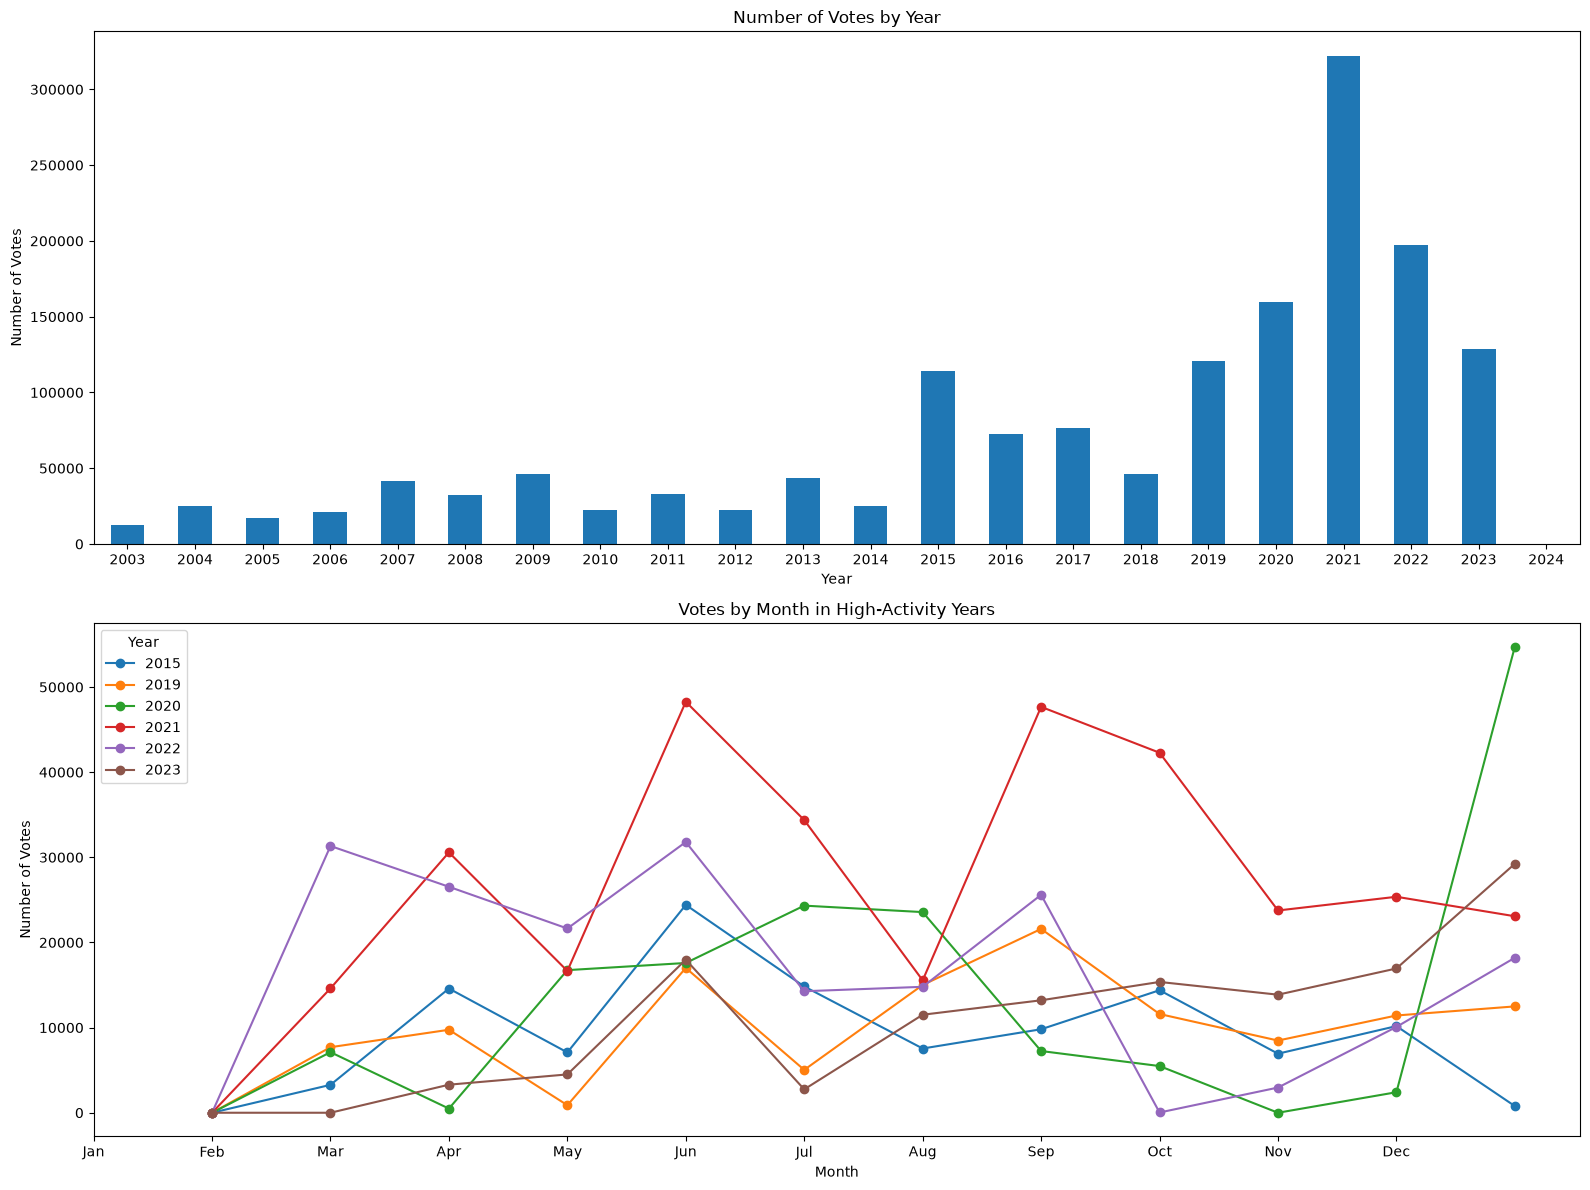

Saved figure: outputs/figures/vote_share_by_year_and_month.png


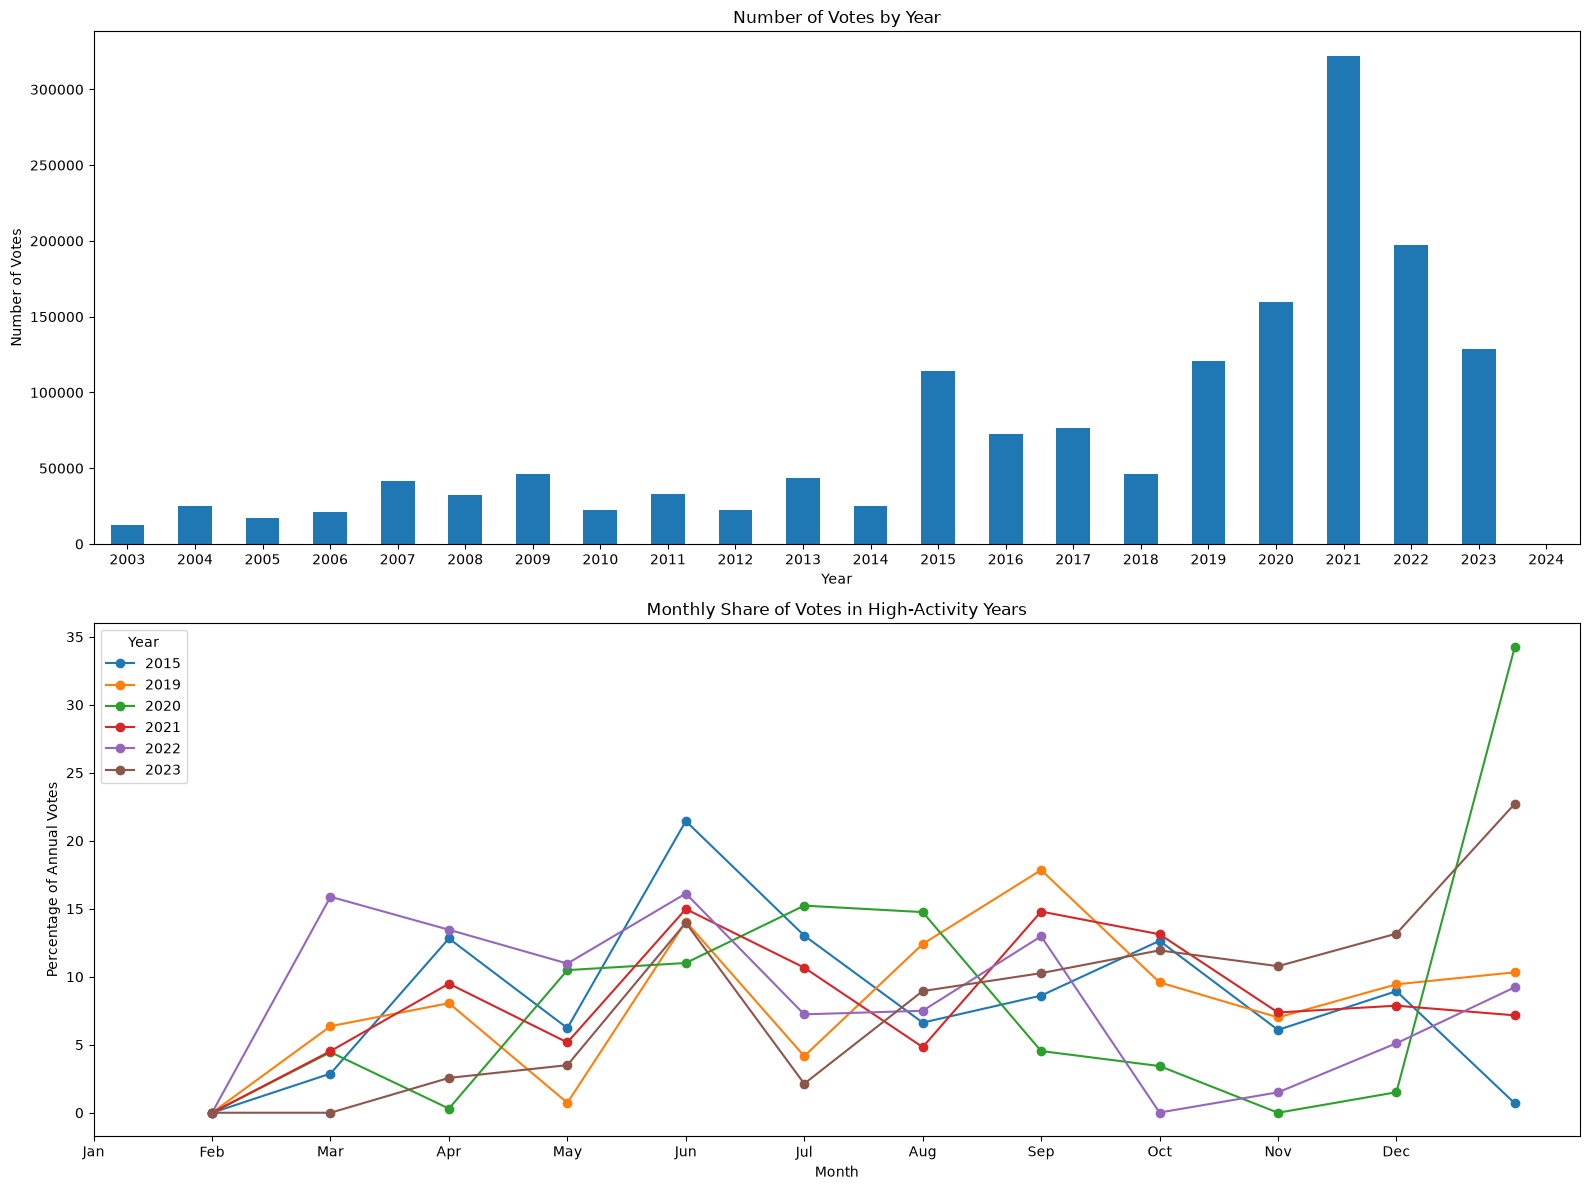

In [17]:
# =============================================================================
# 16. VOTING ACTIVITY BY YEAR AND MONTH
# =============================================================================

votes_by_year = (
    superplanilha_red.groupby("ano")
    .size()
    .sort_index()
)

votes_by_year_month = (
    superplanilha_red.groupby(["ano", "mes"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=range(1, 13), fill_value=0)
    .sort_index()
)

monthly_vote_share = (
    votes_by_year_month
    .div(votes_by_year_month.sum(axis=1), axis=0)
    .mul(100)
)

available_high_vote_years = [
    year for year in HIGH_VOTE_YEARS
    if year in monthly_vote_share.index
]

high_vote_year_share = monthly_vote_share.loc[
    available_high_vote_years
].copy()

high_vote_year_share.columns = MONTH_LABELS
high_vote_year_share["SUM"] = high_vote_year_share.sum(axis=1)

display(high_vote_year_share.reset_index())

save_table(
    votes_by_year.rename("Votes"),
    "votes_by_year.csv",
)
save_table(
    votes_by_year_month,
    "votes_by_year_and_month.csv",
)
save_table(
    monthly_vote_share,
    "monthly_vote_share_by_year.csv",
)

high_activity_years = votes_by_year.loc[
    votes_by_year > 100_000
].index

# Absolute monthly activity
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))

votes_by_year.plot(kind="bar", ax=ax1)
ax1.set_title("Number of Votes by Year")
ax1.set_ylabel("Number of Votes")
ax1.set_xlabel("Year")
ax1.tick_params(axis="x", rotation=0)

if len(high_activity_years):
    votes_by_year_month.loc[high_activity_years].T.plot(
        ax=ax2,
        linestyle="-",
        marker="o",
    )
    ax2.legend(title="Year")

ax2.set_title("Votes by Month in High-Activity Years")
ax2.set_ylabel("Number of Votes")
ax2.set_xlabel("Month")
ax2.set_xticks(range(12))
ax2.set_xticklabels(MONTH_LABELS)

fig.tight_layout()
save_figure(fig, "votes_by_year_and_month.png")
plt.show()

# Percentage monthly activity
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))

votes_by_year.plot(kind="bar", ax=ax1)
ax1.set_title("Number of Votes by Year")
ax1.set_ylabel("Number of Votes")
ax1.set_xlabel("Year")
ax1.tick_params(axis="x", rotation=0)

if len(high_activity_years):
    monthly_vote_share.loc[high_activity_years].T.plot(
        ax=ax2,
        linestyle="-",
        marker="o",
    )
    ax2.legend(title="Year")

ax2.set_title("Monthly Share of Votes in High-Activity Years")
ax2.set_ylabel("Percentage of Annual Votes")
ax2.set_xlabel("Month")
ax2.set_xticks(range(12))
ax2.set_xticklabels(MONTH_LABELS)

fig.tight_layout()
save_figure(fig, "vote_share_by_year_and_month.png")
plt.show()

# Compatibility aliases from the original notebook.
votos_por_ano = votes_by_year
votos_por_ano_mes = votes_by_year_month
votos_por_ano_mes_percent = monthly_vote_share
anos_mais_votados = high_vote_year_share


## 17. Outputs

Generated files are organized automatically as:

- `outputs/figures/`
- `outputs/tables/`
- `outputs/data/`


In [18]:
# =============================================================================
# 17. OUTPUT SUMMARY
# =============================================================================

print("=" * 80)
print("ANALYSIS COMPLETED")
print("=" * 80)
print(f"Figures       : {FIGURE_DIR.resolve()}")
print(f"Tables        : {TABLE_DIR.resolve()}")
print(f"Processed data: {OUTPUT_DATA_DIR.resolve()}")
print("=" * 80)


ANALYSIS COMPLETED
Figures       : /home/carlos/Carlos/Bahia_Clean_Project/outputs/figures
Tables        : /home/carlos/Carlos/Bahia_Clean_Project/outputs/tables
Processed data: /home/carlos/Carlos/Bahia_Clean_Project/outputs/data
